#**Capa Bronze**

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
PALETA = {
    "negro": "#2E2929", "blanco": "#F1F1F1", "amarillo": "#FFD400", "naranja": "#FF8120",
    "violeta": "#A35BCF", "azul": "#1DB8D3", "verde": "#14C48A", "rosa": "#EFA6C2",
}
PRINCIPAL = PALETA["verde"]
SECUNDARIO = PALETA["azul"]
ALERTA = PALETA["naranja"]
ATENUADO = PALETA["negro"]
GRID = PALETA["negro"]

In [ ]:
def construir_resumen(df_wide, col_saldo, prefijo):
    resumen = (
        df_wide.dropna(subset=[col_saldo])
        .sort_values(["numero_id", "año_mes"])
        .groupby("numero_id")[col_saldo]
        .agg(
            **{
                f"saldo_{prefijo}_mediana_historica": "median",
                f"saldo_{prefijo}_min": "min",
                f"saldo_{prefijo}_max": "max",
                f"saldo_{prefijo}_ultimo": "last",
                f"n_snapshots_{prefijo}": "count",
            }
        )
        .reset_index()
    )

    resumen[f"saldo_{prefijo}_rango_relativo"] = np.where(
        resumen[f"saldo_{prefijo}_max"] == resumen[f"saldo_{prefijo}_min"],
        0,
        (resumen[f"saldo_{prefijo}_max"] - resumen[f"saldo_{prefijo}_min"])
        / resumen[f"saldo_{prefijo}_mediana_historica"].replace(0, np.nan),
    )

    resumen[f"confianza_historia_{prefijo}"] = pd.cut(
        resumen[f"n_snapshots_{prefijo}"],
        bins=[0, 1, 3, resumen[f"n_snapshots_{prefijo}"].max()],
        labels=["dato_unico", "dato_parcial", "dato_robusto"],
    )
    return resumen

In [ ]:
def marcar_no_aplica(serie):
    if "no_aplica" not in serie.cat.categories:
        serie = serie.cat.add_categories("no_aplica")
    return serie.fillna("no_aplica")

## **Lectura de archivos .db**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def db_to_dataframe(db_path, table_name=None):
    conn = sqlite3.connect(db_path)
    try:
        if table_name is None:
            table_name = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table' LIMIT 1;",
                conn
            ).iloc[0, 0]

        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
        return df
    finally:
        conn.close()

In [ ]:
df_clientes = db_to_dataframe("/content/drive/MyDrive/data/clientes.db")

In [ ]:
df_crean_aho_cte = db_to_dataframe("/content/drive/MyDrive/data/crean_aho_cte.db")

In [ ]:
df_bolsillos = db_to_dataframe("/content/drive/MyDrive/data/crean_bolsillos.db")

In [ ]:
df_crean_fiducuenta = db_to_dataframe("/content/drive/MyDrive/data/crean_fiducuenta.db")

In [ ]:
df_crean_inv_virtual_cdt = db_to_dataframe("/content/drive/MyDrive/data/crean_inv_virtual_cdt.db")

In [ ]:
df_estimador_ing = db_to_dataframe("/content/drive/MyDrive/data/estimador_ing.db")

In [ ]:
df_invesbot = db_to_dataframe("/content/drive/MyDrive/data/invesbot.db")

In [ ]:
# Convertir los numero_id en str debido a los identificadores negativos. Para evitar que se realicen operaciones con los id.
df_clientes["numero_id"] = df_clientes["numero_id"].astype(str)
df_crean_aho_cte['numero_id'] = df_crean_aho_cte['numero_id'].astype(str)
df_bolsillos['numero_id'] = df_bolsillos['numero_id'].astype(str)
df_crean_fiducuenta['numero_id'] = df_crean_fiducuenta['numero_id'].astype(str)
df_crean_inv_virtual_cdt['numero_id'] = df_crean_inv_virtual_cdt['numero_id'].astype(str)
df_estimador_ing['numero_id'] = df_estimador_ing['numero_id'].astype(str)
df_invesbot['numero_id'] = df_invesbot['numero_id'].astype(str)

## Análisis de registros a nivel temporal

La solución pedida tiene dos objetivos que dependen directamente de qué tan buena es la historia disponible: identificar quién tiene mayor probabilidad de adoptar la nueva App, y estimar cuánto podría invertir en los próximos 12 meses (ambos), además, tienen que sostener después segmentación, priorización comercial y dimensionamiento de negocio, no solo un número aislado por cliente. Antes de construir nada sobre estas siete fuentes, hay que verificar que se pueda cumplir lo que pide el modelo de datos: granularidad adecuada (una fila por cliente-mes, no duplicada), consistencia entre identificadores (que numero_id cruce limpio entre fuentes) y trazabilidad de las variables (poder decir, para cada cliente, cuánta evidencia real respalda cada número que se le calcula).

Ese último punto (trazabilidad) es también lo que determina si la estimación a 12 meses puede apoyarse en una trayectoria real o si hay que recurrir a un supuesto: si la historia disponible es corta y dispersa, no hay con qué modelar una tendencia, y el diseño se ajusta a estadísticos descriptivos por cliente (mediana, mínimo, máximo, estabilidad del saldo entre observaciones) que aproximan comportamiento típico sin necesitar una serie de tiempo completa. Verificarlo aquí, antes de cualquier limpieza específica de tabla, es lo que permite tomar esa decisión con evidencia y no por defecto.

In [ ]:
tablas_temporales = {
    "Ahorro/Corriente": (df_crean_aho_cte, False),
    "Bolsillos": (df_bolsillos, False),
    "Fiducuenta": (df_crean_fiducuenta, False),
    "CDT/Inv. Virtual": (df_crean_inv_virtual_cdt, True),  # tiene columna 'producto', se incluye en la clave de duplicados
}
colores_series = [PRINCIPAL, SECUNDARIO, ALERTA, PALETA["violeta"]]

for df, _ in tablas_temporales.values():
    df["fecha"] = pd.to_datetime(df["fecha"])
    df["año_mes"] = df["fecha"].dt.to_period("M")

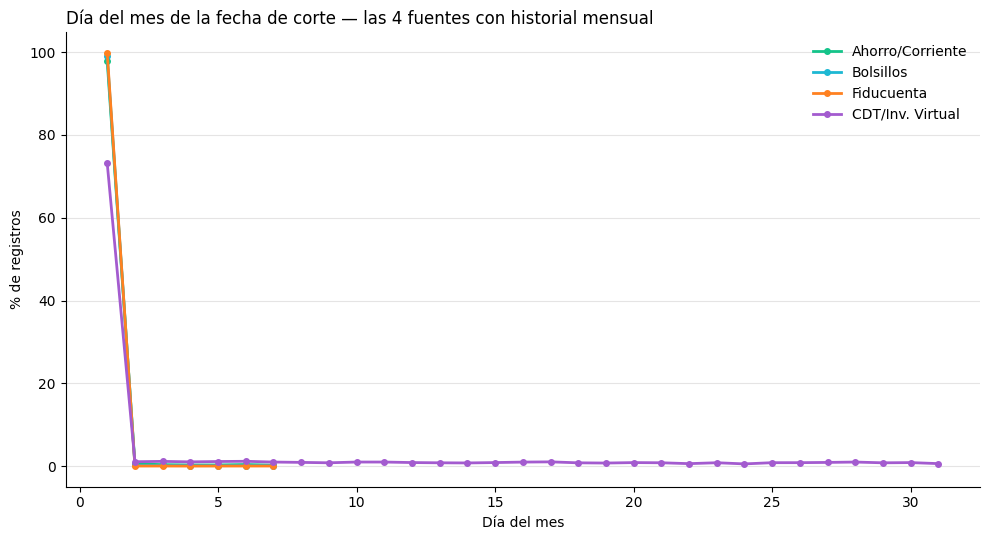

In [ ]:
# ---------- Gráfica 1: día del mes de la fecha de corte ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
for (nombre, (df, _)), color in zip(tablas_temporales.items(), colores_series):
    dia = df["fecha"].dt.day.value_counts(normalize=True).sort_index() * 100
    ax.plot(dia.index, dia.values, "o-", color=color, linewidth=2, label=nombre, markersize=4)
ax.set_xlabel("Día del mes")
ax.set_ylabel("% de registros")
ax.set_title("Día del mes de la fecha de corte — las 4 fuentes con historial mensual", fontsize=12, loc="left")
ax.legend(frameon=False)
ax.grid(axis="y", color=GRID, alpha=0.12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dia_corte_consolidado.png", dpi=110)
plt.show()

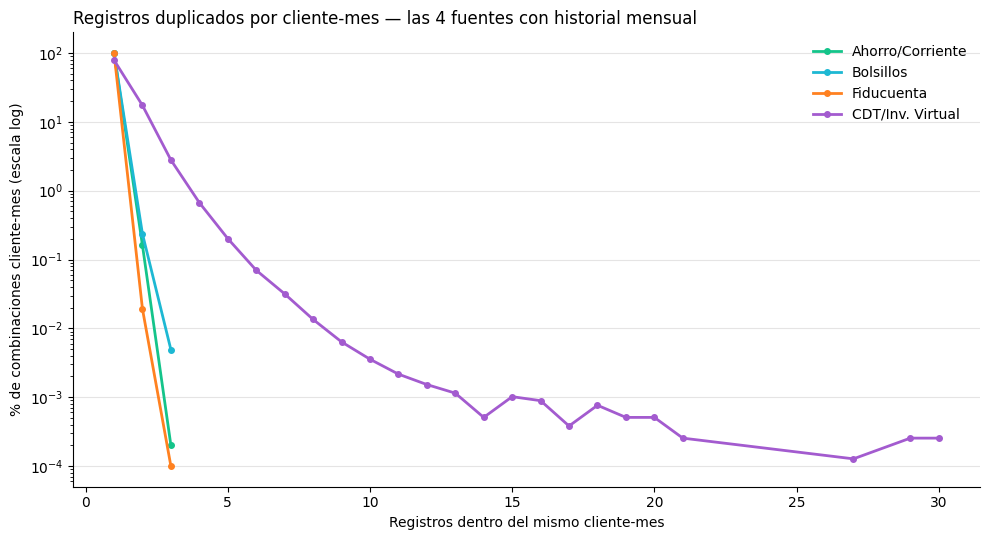

In [ ]:
# ---------- Gráfica 2: registros duplicados por cliente-mes ----------
fig, ax = plt.subplots(figsize=(10, 5.5))
for (nombre, (df, incluye_producto)), color in zip(tablas_temporales.items(), colores_series):
    claves = ["numero_id", "año_mes", "producto"] if incluye_producto else ["numero_id", "año_mes"]
    conteo = df.groupby(claves).size().value_counts(normalize=True).sort_index() * 100
    ax.plot(conteo.index, conteo.values, "o-", color=color, linewidth=2, label=nombre, markersize=4)
ax.set_yscale("log")
ax.set_xlabel("Registros dentro del mismo cliente-mes")
ax.set_ylabel("% de combinaciones cliente-mes (escala log)")
ax.set_title("Registros duplicados por cliente-mes — las 4 fuentes con historial mensual", fontsize=12, loc="left")
ax.legend(frameon=False)
ax.grid(axis="y", color=GRID, alpha=0.12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("registros_cliente_mes_consolidado.png", dpi=110)
plt.show()

`construir_resumen()` se reutiliza para los siete productos con historial mensual (ahorro, corriente, bolsillos, fiducuenta, CDT, inversión virtual, invesbot), así que el criterio de qué estadísticos calcular se decide una sola vez, no producto por producto. Es un supuesto anclado en cómo se comporta este dato a lo largo de los ~13 meses de historia disponible: el panel es corto y disperso — la mayoría de clientes aparece muy pocas veces, ninguno con el historial mensual completo —, y el saldo de un mismo cliente suele variar mucho entre una observación y la siguiente. Por eso se calcula mediana (nivel típico, robusto a un dato puntual atípico) y no promedio; se conservan mínimo y máximo por separado, para no borrar esa volatilidad — es comportamiento real del cliente, no ruido a promediar —; `n_snapshots` y `confianza_historia` traducen cuántas observaciones sostienen esos números, porque no es lo mismo un saldo típico calculado sobre 1 dato que sobre 8; y `rango_relativo` normaliza esa volatilidad contra el propio nivel del cliente, para que sea comparable entre alguien con saldos grandes y alguien con saldos pequeños. Cada uno de estos puntos se confirma con evidencia real más abajo, en la sección de ahorro/corriente — la primera fuente donde se aplica la función.

## Limpieza tabla clientes.db

In [ ]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860231 entries, 0 to 860230
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   numero_id                860231 non-null  object 
 1   grupo_edad               860231 non-null  object 
 2   desc_genero              860138 non-null  object 
 3   desc_segmento            860231 non-null  object 
 4   desc_tipo_de_vivienda    268532 non-null  object 
 5   ingresos_mensuales       859982 non-null  float64
 6   total_egresos_mensuales  859982 non-null  float64
 7   total_activos            859982 non-null  float64
 8   total_pasivos            859982 non-null  float64
 9   total_patrimonio         859971 non-null  float64
dtypes: float64(5), object(5)
memory usage: 65.6+ MB


In [ ]:
df_clientes.isnull().sum()

,0
numero_id,0
grupo_edad,0
desc_genero,93
desc_segmento,0
desc_tipo_de_vivienda,591699
ingresos_mensuales,249
total_egresos_mensuales,249
total_activos,249
total_pasivos,249
total_patrimonio,260


In [ ]:
df_clientes["grupo_edad"].value_counts()

,count
grupo_edad,
36-49,236762
26-35,212491
50-65,163234
65+,137339
18-25,110405


In [ ]:
df_clientes['desc_segmento'].value_counts()

,count
desc_segmento,
personal,645978
plus,196072
preferencial,18181


### Tratamiento de duplicados

In [ ]:
df_clientes['numero_id'].duplicated().value_counts()

,count
numero_id,
False,860223
True,8


In [ ]:
dup_ids = df_clientes.loc[df_clientes["numero_id"].duplicated(keep=False), "numero_id"]
filas_dup = df_clientes[df_clientes["numero_id"].isin(dup_ids)].sort_values("numero_id")

# ¿son copias identicas o difieren en alguna columna? nunique()==1 en todas las columnas -> duplicados verdaderos
variacion_por_grupo = filas_dup.groupby("numero_id").nunique()
cols_que_varian = variacion_por_grupo.columns[(variacion_por_grupo > 1).any()]
print(f"IDs duplicados: {dup_ids.nunique():,} | filas involucradas: {len(filas_dup):,}")
print(f"Columnas donde los duplicados DIFIEREN entre si: {list(cols_que_varian)}")

IDs duplicados: 8 | filas involucradas: 16
Columnas donde los duplicados DIFIEREN entre si: []


In [ ]:
# Eliminar duplicados para mantener clientes con identificador único
df_clientes = df_clientes.drop_duplicates(subset='numero_id', keep='first')

In [ ]:
df_clientes

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio
0,8805210490649048784,65+,masculino,preferencial,None,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08
...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,masculino,plus,None,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08
860227,6034010744462256034,36-49,masculino,plus,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08
860228,3918722977197857898,50-65,masculino,plus,None,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08
860229,-8439226781033547229,50-65,femenino,plus,None,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07


### Tratamiento de nulos y vacíos

In [ ]:
df_clientes['desc_genero'].value_counts()

,count
desc_genero,
femenino,472622
masculino,387430
no binario,45
trans,33


In [ ]:
# desc_genero: imputar nulos y vacíos a "no informa"
df_clientes["desc_genero"] = (
    df_clientes["desc_genero"]
    .replace("", pd.NA)
    .fillna("no informa")
)

In [ ]:
# desc_tipo_de_vivienda: mismo criterio de imputar nulos y vacíos a "no informa", unificando con la categoría ya existente

df_clientes["desc_tipo_de_vivienda"] = df_clientes["desc_tipo_de_vivienda"].replace("", pd.NA)

df_clientes["vivienda_declarada"] = df_clientes["desc_tipo_de_vivienda"].notna().astype(int)

df_clientes["desc_tipo_de_vivienda"] = (
    df_clientes["desc_tipo_de_vivienda"]
    .str.upper()
    .fillna("NO INFORMA")
)

In [ ]:
df_clientes['desc_tipo_de_vivienda'].value_counts()

,count
desc_tipo_de_vivienda,
NO INFORMA,609881
FAMILIAR,129359
PROPIA,75034
ARRENDADA,45949


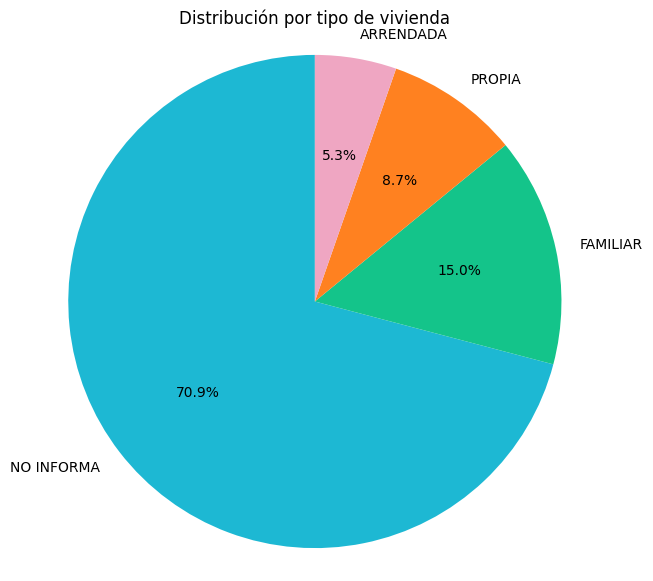

In [ ]:
frecuencia = df_clientes["desc_tipo_de_vivienda"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    frecuencia.values,
    labels=frecuencia.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[PALETA['azul'], PALETA['verde'], PALETA['naranja'], PALETA['rosa'], PALETA['violeta']]
)
plt.title("Distribución por tipo de vivienda")
plt.axis("equal")
plt.show()

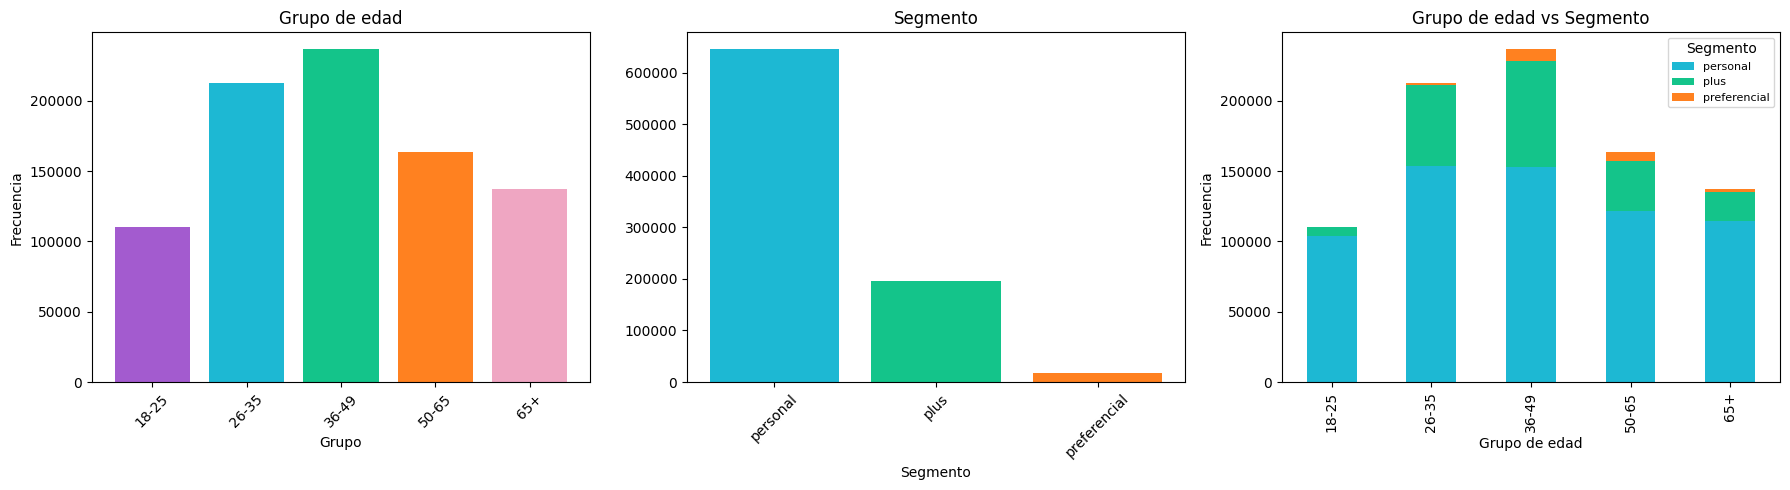

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Grupo de edad
edad = df_clientes["grupo_edad"].value_counts().sort_index()
ax[0].bar(edad.index.astype(str), edad.values, color=[PALETA['violeta'], PALETA['azul'], PALETA['verde'], PALETA['naranja'], PALETA['rosa']])
ax[0].set_title("Grupo de edad")
ax[0].set_xlabel("Grupo")
ax[0].set_ylabel("Frecuencia")
ax[0].tick_params(axis="x", rotation=45)

# Segmento
segmento = df_clientes["desc_segmento"].value_counts()
ax[1].bar(segmento.index.astype(str), segmento.values, color=[PALETA['azul'], PALETA['verde'], PALETA['naranja']])
ax[1].set_title("Segmento")
ax[1].set_xlabel("Segmento")
ax[1].tick_params(axis="x", rotation=45)

# Grupo de edad vs Segmento
mix = (
    df_clientes
    .groupby(["grupo_edad", "desc_segmento"])
    .size()
    .unstack(fill_value=0)
)

mix.plot(kind="bar", stacked=True, ax=ax[2], color=[PALETA['azul'], PALETA['verde'], PALETA['naranja']])
ax[2].set_title("Grupo de edad vs Segmento")
ax[2].set_xlabel("Grupo de edad")
ax[2].set_ylabel("Frecuencia")
ax[2].legend(title="Segmento", fontsize=8)

plt.tight_layout()
plt.show()

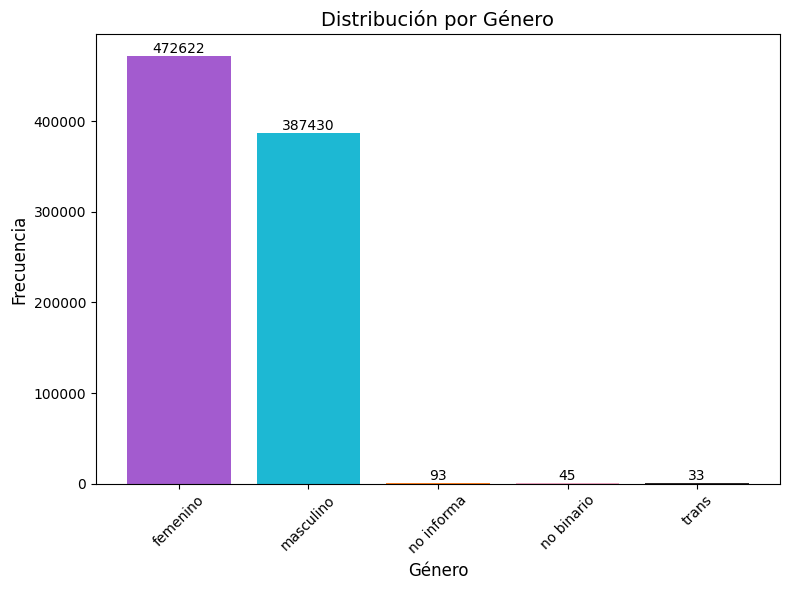

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
genero_counts = df_clientes['desc_genero'].value_counts()

bars = ax.bar(genero_counts.index, genero_counts.values, color=[PALETA['violeta'], PALETA['azul'], PALETA['naranja'], PALETA['rosa'], PALETA['negro']])
ax.set_title('Distribución por Género', fontsize=14)
ax.set_xlabel('Género', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 1), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Winsorización

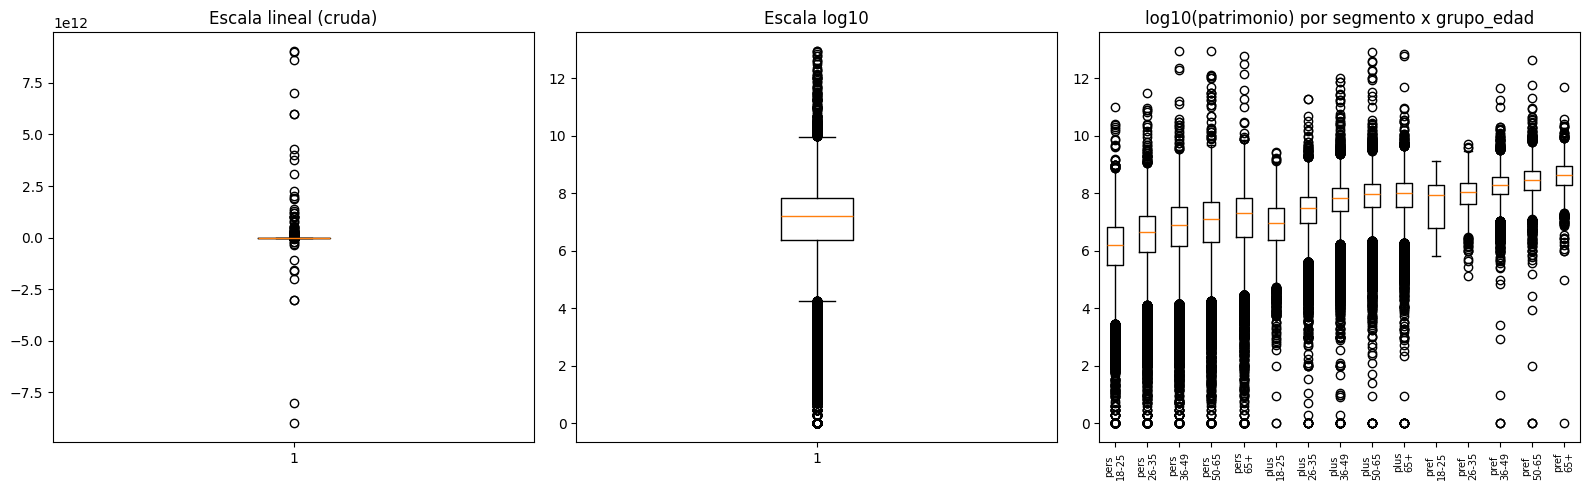

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

data = df_clientes["total_patrimonio"].dropna()
axes[0].boxplot(data)
axes[0].set_title("Escala lineal (cruda)")

data_log = np.log10(data[data > 0])
axes[1].boxplot(data_log)
axes[1].set_title("Escala log10")

plot_df = df_clientes.dropna(subset=["total_patrimonio"])
plot_df = plot_df[plot_df["total_patrimonio"] > 0].copy()
plot_df["log_patrimonio"] = np.log10(plot_df["total_patrimonio"])

orden = ["18-25", "26-35", "36-49", "50-65", "65+"]
grupos, labels = [], []
for seg in ["personal", "plus", "preferencial"]:
    for edad in orden:
        sub = plot_df[(plot_df["desc_segmento"] == seg) & (plot_df["grupo_edad"] == edad)]["log_patrimonio"]
        grupos.append(sub)
        labels.append(f"{seg[:4]}\n{edad}")

axes[2].boxplot(grupos, tick_labels=labels)
axes[2].tick_params(axis="x", rotation=90, labelsize=7)
axes[2].set_title("log10(patrimonio) por segmento x grupo_edad")

plt.tight_layout()
plt.show()


Los outliers extremos de patrimonio no son un caso aislado: `total_activos`, `total_pasivos` y `total_egresos_mensuales` comparten el mismo origen (fichas financieras declaradas) y pueden llegar a valores de billones de pesos que no corresponden a ningún cliente retail real, y como el patrimonio se deriva de activos y pasivos, un outlier en cualquiera de los dos termina distorsionando también el patrimonio calculado. Por eso las cuatro variables se tratan con el mismo criterio: solo se capan los casos verdaderamente extremos (>1 billón COP) al P99 de su propio grupo `segmento × grupo_edad`, para no aplastar la variación legítima del resto de la base. `total_patrimonio`, al ser la única que puede tomar valores negativos (patrimonio = activos − pasivos), recibe el mismo tratamiento simétrico también en su extremo inferior.

In [ ]:
cols = ["ingresos_mensuales", "total_egresos_mensuales", "total_activos", "total_pasivos", "total_patrimonio"]
nombres = ["Ingresos", "Egresos", "Activos", "Pasivos", "Patrimonio"]

def transformar(s):
    # log1p con signo: soporta ceros y negativos (patrimonio tiene ambos)
    return np.sign(s) * np.log1p(np.abs(s))

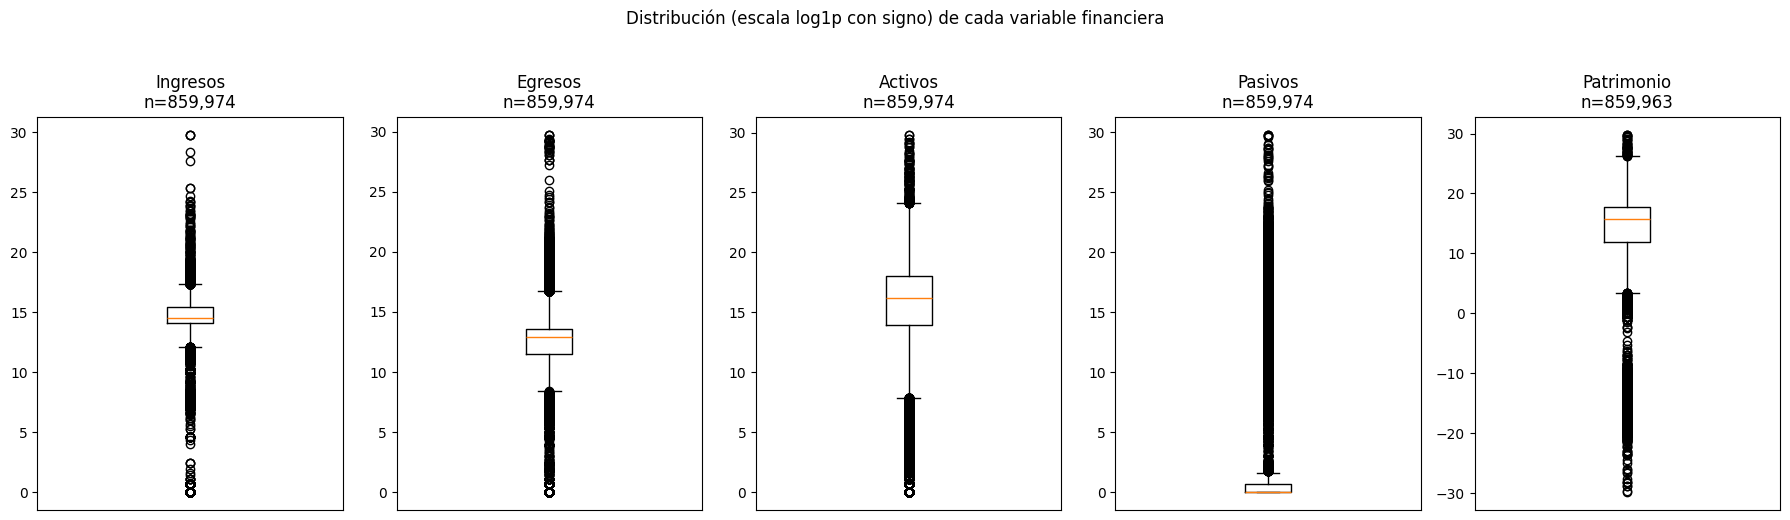

            nulos   ceros  negativos         media     mediana        skew
variable                                                                  
Ingresos      249    9296          0  3.932340e+07   2000000.0  520.344321
Egresos       249  136249          0  1.478023e+08    400000.0  215.205891
Activos       249   97100          0  1.997919e+08  10902000.0  293.686786
Pasivos       249  644627          0  9.687762e+07         0.0  334.007665
Patrimonio    260  164331       6173  1.311168e+08   7000000.0  110.050246


In [ ]:
fig1, axes1 = plt.subplots(1, 5, figsize=(18, 5))
resumen = []

for ax, col, nombre in zip(axes1, cols, nombres):
    serie = df_clientes[col].dropna()
    ax.boxplot(transformar(serie))
    ax.set_title(f"{nombre}\nn={len(serie):,}")
    ax.set_xticks([])
    resumen.append({
        "variable": nombre,
        "nulos": df_clientes[col].isna().sum(),
        "ceros": (serie == 0).sum(),
        "negativos": (serie < 0).sum(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "skew": serie.skew(),
    })

fig1.suptitle("Distribución (escala log1p con signo) de cada variable financiera", y=1.03)
plt.tight_layout()
plt.show()

resumen_df = pd.DataFrame(resumen).set_index("variable")
print(resumen_df)


Las 5 variables tienen skewness extremo (110 a 520, cuando una distribución normal tiene skew≈0). No es un problema aislado de una columna, es el comportamiento típico de variables financieras: la mayoría de clientes se concentra en un rango bajo-medio, y una minoría de valores muy altos (o muy negativos, en el caso de Patrimonio) estira la cola. Por eso la media no es representativa. Por lo tanto, cualquier imputación de nulos debe usar mediana, nunca promedio, el promedio heredaría el sesgo de esos extremos y asignaría valores irreales a los clientes con datos faltantes.

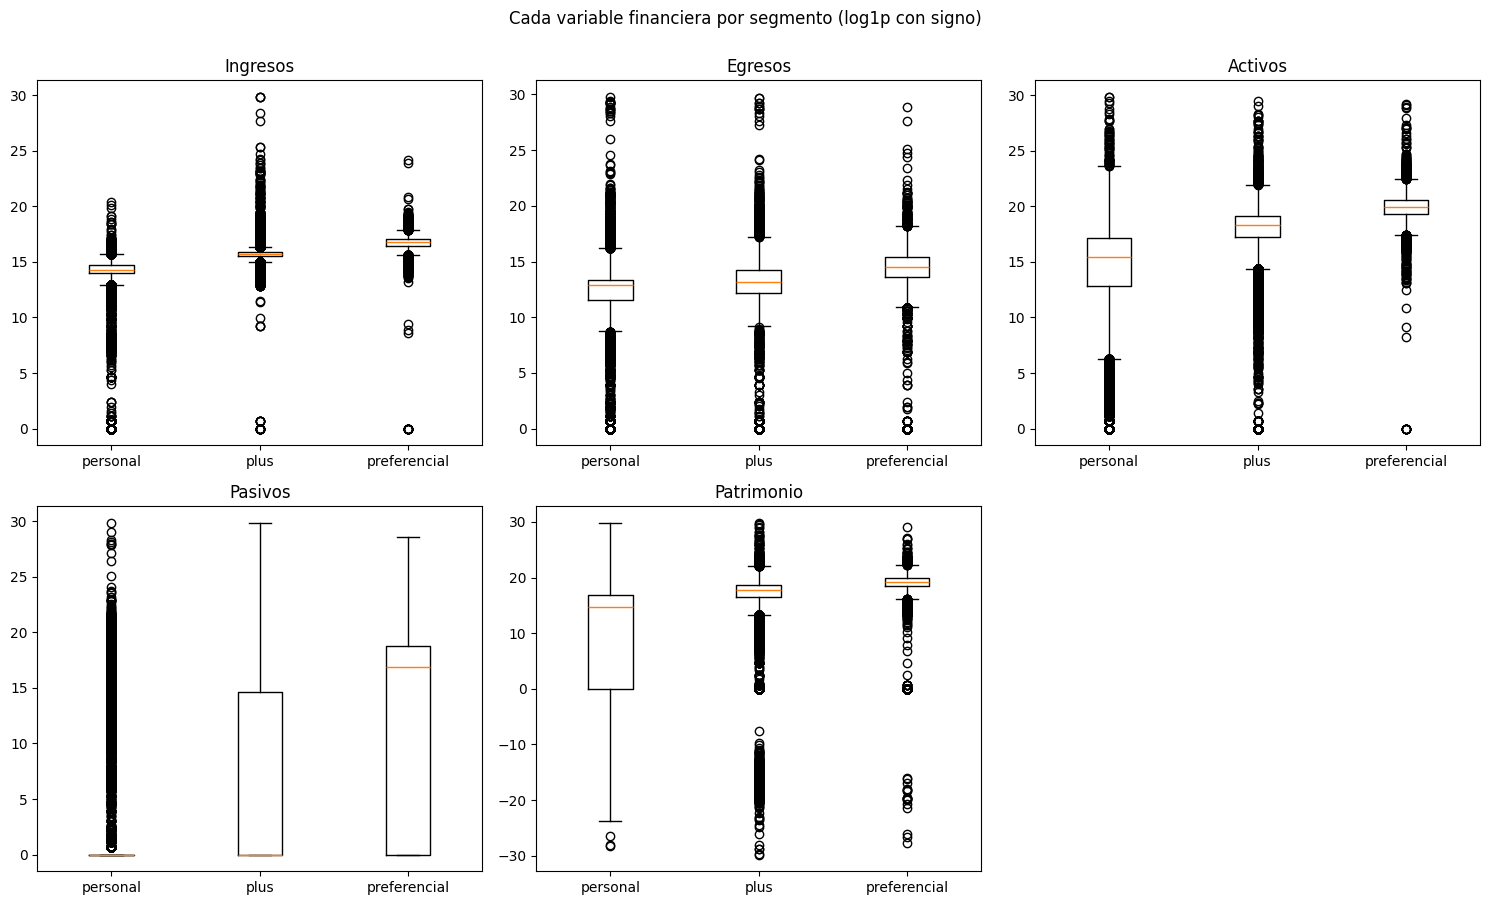

In [ ]:
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
axes2 = axes2.flatten()

for ax, col, nombre in zip(axes2, cols, nombres):
    grupos, labels = [], []
    for seg in ["personal", "plus", "preferencial"]:
        sub = df_clientes.loc[df_clientes["desc_segmento"] == seg, col].dropna()
        grupos.append(transformar(sub))
        labels.append(seg)
    ax.boxplot(grupos, tick_labels=labels)
    ax.set_title(nombre)

axes2[-1].axis("off")
fig2.suptitle("Cada variable financiera por segmento (log1p con signo)", y=1.0)
plt.tight_layout()
plt.show()


La mediana se desplaza de forma visible entre segmentos en las 5 variables, más marcado en Activos y Patrimonio, más sutil en Ingresos/Egresos. Un caso particular vale la pena mencionar: en Pasivos, la mediana es 0 tanto en personal como en plus (porque ~75% de la base no tiene deuda registrada), y solo sube en preferencial. Es decir, el comportamiento de deuda no es igual entre segmentos, y una imputación que ignore esto estaría mal calibrada para al menos un grupo. La imputación debe hacerse por grupo (segmento × grupo_edad), no con una mediana global

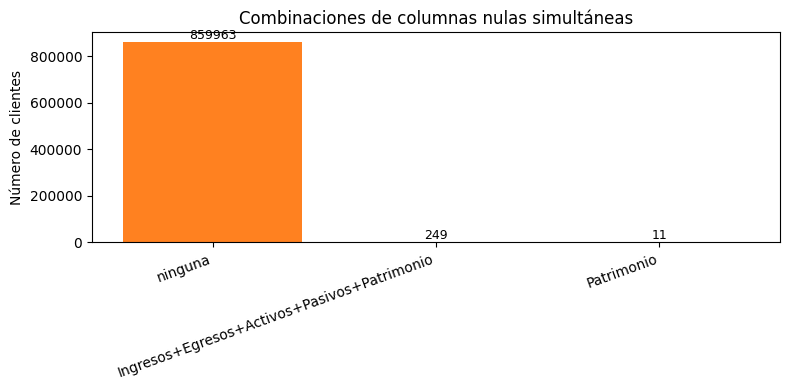

In [ ]:
patron = df_clientes[cols].isnull().astype(int)
patron_str = patron.astype(str).agg("".join, axis=1)
conteo_patrones = patron_str.value_counts()
conteo_patrones = conteo_patrones[conteo_patrones > 0]

etiquetas = []
for p in conteo_patrones.index:
    faltantes = [nombres[i] for i, c in enumerate(p) if c == "1"]
    etiquetas.append("+".join(faltantes) if faltantes else "ninguna")

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.bar(etiquetas, conteo_patrones.values, color=PALETA['naranja'])
ax3.set_ylabel("Número de clientes")
ax3.set_title("Combinaciones de columnas nulas simultáneas")
for i, v in enumerate(conteo_patrones.values):
    ax3.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Solo existen dos patrones en toda la base de 860,223 clientes: 249 clientes sin ninguna de las 5 variables, y 11 clientes sin únicamente Patrimonio. No hay combinaciones parciales (nadie tiene, por ejemplo, solo Ingresos y Pasivos nulos), el vacío es todo-o-nada. Esto descarta que sea un problema de captura aleatoria por campo; es un bloque completo de clientes sin ficha financiera cargada. Con un patrón tan limpio, bastan 2 flags de trazabilidad (sin_info_financiera para las 249, patrimonio_no_reportado para las 260) en vez de uno por columna (la estructura del dato no lo exige).

In [ ]:
cols_a_winsorizar = ["total_activos", "total_pasivos", "total_egresos_mensuales", "total_patrimonio"]

for col in cols_a_winsorizar:
    p99_grupo = df_clientes.groupby(["desc_segmento", "grupo_edad"])[col].transform(
        lambda s: s.quantile(0.99)
    )
    extremos = df_clientes[col] > 1e12
    print(f"{col}: clientes capados (>1 billón) = {extremos.sum()}")
    df_clientes.loc[extremos, col] = p99_grupo[extremos]

# patrimonio es la unica variable que puede ser negativa (patrimonio = activos - pasivos),
# asi que ademas del extremo superior tambien se trata su extremo inferior con el mismo criterio
p1_grupo = df_clientes.groupby(["desc_segmento", "grupo_edad"])["total_patrimonio"].transform(
    lambda s: s.quantile(0.01)
)
extremos_inf = df_clientes["total_patrimonio"] < -1e12
print(f"total_patrimonio: clientes capados (<-1 billón) = {extremos_inf.sum()}")
df_clientes.loc[extremos_inf, "total_patrimonio"] = p1_grupo[extremos_inf]

total_activos: clientes capados (>1 billón) = 21
total_pasivos: clientes capados (>1 billón) = 17
total_egresos_mensuales: clientes capados (>1 billón) = 33
total_patrimonio: clientes capados (>1 billón) = 19
total_patrimonio: clientes capados (<-1 billón) = 8


In [ ]:
cols_financieras = ["ingresos_mensuales", "total_egresos_mensuales", "total_activos", "total_pasivos", "total_patrimonio"]

df_clientes["sin_info_financiera"] = df_clientes[cols_financieras].isnull().all(axis=1).astype(int)
df_clientes["patrimonio_no_reportado"] = df_clientes["total_patrimonio"].isnull().astype(int)

grupo = ["desc_segmento", "grupo_edad"]
for col in cols_financieras:
    mediana_grupo = df_clientes.groupby(grupo)[col].transform("median")
    df_clientes[col] = df_clientes[col].fillna(mediana_grupo)
    df_clientes[col] = df_clientes[col].fillna(df_clientes[col].median())


In [ ]:
df_clientes.isnull().sum()

,0
numero_id,0
grupo_edad,0
desc_genero,0
desc_segmento,0
desc_tipo_de_vivienda,0
ingresos_mensuales,0
total_egresos_mensuales,0
total_activos,0
total_pasivos,0
total_patrimonio,0


Las 5 variables financieras de clientes tienen distribuciones fuertemente sesgadas (skew 110-520), por lo que toda imputación se hace con mediana y no con promedio. Además, esa mediana varía de forma material según segmento y grupo de edad, por lo que se calcula por grupo. Los nulos, por su parte, siguen un patrón binario simple (todo o nada en 260 de 860,223 clientes, 0.03% de la base), lo que permite resolverlos con solo dos columnas de flag sin perder trazabilidad."

## Limpieza tabla crean_aho_cte.db

In [ ]:
df_crean_aho_cte.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   fecha      1000000 non-null  object 
 1   numero_id  1000000 non-null  int64  
 2   producto   1000000 non-null  object 
 3   saldo      1000000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 30.5+ MB


In [ ]:
df_crean_aho_cte.isnull().sum()

,0
fecha,0
numero_id,0
producto,0
saldo,0


In [ ]:
df_crean_aho_cte.duplicated(subset=["fecha", "numero_id", "producto"]).sum()

np.int64(0)

In [ ]:
df_crean_aho_cte['producto'].value_counts()

,count
producto,
CUENTA DE AHORRO,987914
CUENTA DE CORRIENTE,12086


In [ ]:
df_crean_aho_cte["fecha"] = pd.to_datetime(df_crean_aho_cte["fecha"])
df_crean_aho_cte["dia_mes"] = df_crean_aho_cte["fecha"].dt.day
df_crean_aho_cte["año_mes"] = df_crean_aho_cte["fecha"].dt.to_period("M")

In [ ]:
df_aho_cte_mensual = (
    df_crean_aho_cte
    .sort_values("fecha")
    .groupby(["numero_id", "año_mes", "producto"], as_index=False)
    .last()
)

### Saldo por producto: volumen y distribución

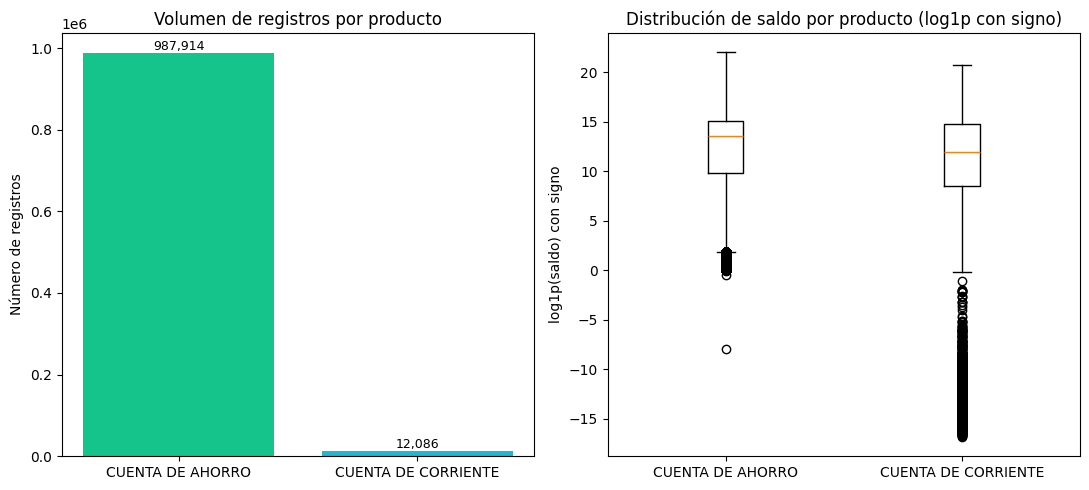

In [ ]:
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 5))

conteo_prod = df_crean_aho_cte["producto"].value_counts()
axes3[0].bar(conteo_prod.index, conteo_prod.values, color=[PALETA['verde'], PALETA['azul']])
axes3[0].set_title("Volumen de registros por producto")
axes3[0].set_ylabel("Número de registros")
for i, v in enumerate(conteo_prod.values):
    axes3[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

grupos, labels = [], []
for prod in df_crean_aho_cte["producto"].unique():
    sub = df_crean_aho_cte.loc[df_crean_aho_cte["producto"] == prod, "saldo"]
    grupos.append(np.sign(sub) * np.log1p(np.abs(sub)))
    labels.append(prod)
axes3[1].boxplot(grupos, tick_labels=labels)
axes3[1].set_title("Distribución de saldo por producto (log1p con signo)")
axes3[1].set_ylabel("log1p(saldo) con signo")

plt.tight_layout()
plt.show()

CUENTA DE AHORRO (987,914 registros) domina casi 82 a 1 sobre CUENTA DE CORRIENTE (12,086), justifica pivotear a formato ancho en vez de mantener filas por producto.

### Saldo negativo por producto

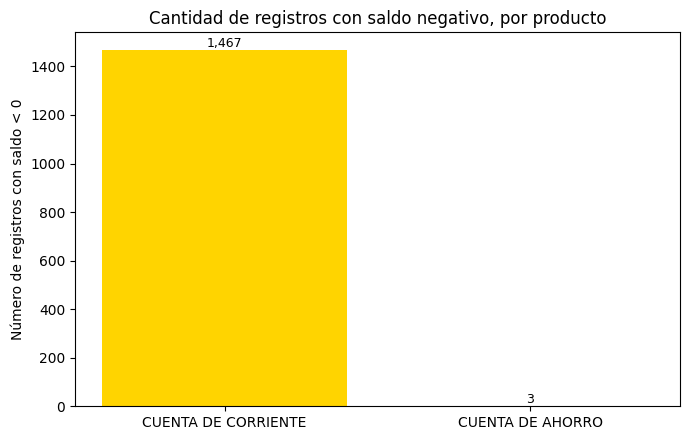

In [ ]:
negativos = df_crean_aho_cte[df_crean_aho_cte["saldo"] < 0]

fig4, ax4 = plt.subplots(figsize=(7, 4.5))
conteo_neg = negativos["producto"].value_counts()
ax4.bar(conteo_neg.index, conteo_neg.values, color=[PALETA['amarillo'], PALETA['azul']])
ax4.set_title("Cantidad de registros con saldo negativo, por producto")
ax4.set_ylabel("Número de registros con saldo < 0")
for i, v in enumerate(conteo_neg.values):
    ax4.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

1,467 registros negativos en CUENTA DE CORRIENTE vs. solo 3 en CUENTA DE AHORRO.
El sobregiro es un comportamiento normal y esperado en cuenta corriente (cupo de crédito asociado), pero es anómalo en una cuenta de ahorro. Tratarlos igual escondería una señal real, un cliente con CUENTA DE AHORRO en negativo es un caso atípico que vale la pena poder filtrar después, no promediarlo con los sobregiros normales de corriente.

In [ ]:
df_aho_cte_mensual["sobregiro"] = (df_aho_cte_mensual["saldo"] < 0).astype(int)
df_aho_cte_mensual["sobregiro_atipico"] = (
    (df_aho_cte_mensual["saldo"] < 0) & (df_aho_cte_mensual["producto"] == "CUENTA DE AHORRO")
).astype(int)


`sobregiro` se codifica como bandera binaria ("¿pasó alguna vez?"), no como el valor del saldo negativo en sí, porque lo que importa para caracterizar al cliente no es cuánto quedó en rojo un mes puntual, sino si ese comportamiento ocurrió, dado lo raro que es (1,467 registros en corriente y 3 en ahorro, sobre casi un millón de registros totales): una magnitud continua sería casi toda ceros y un solo número atípico, sin información útil para modelar. Se calcula sobre `df_aho_cte_mensual` (el panel ya colapsado a un registro por cliente-mes) y no sobre `df_crean_aho_cte` (el dato crudo, que puede tener varias filas por mes) para que la agregación posterior a nivel cliente (`.groupby("numero_id").agg(max)`) cuente eventos-mes reales, no duplicados por múltiples cortes dentro del mismo mes.

### Pivote de tabla para numero_id × año_mes

In [ ]:
clientes_ambos_productos = (
    df_aho_cte_mensual
    .groupby(["numero_id", "año_mes"])["producto"]
    .nunique()
)
n_ambos = (clientes_ambos_productos > 1).sum()
print(f"Cliente-mes con ambos productos: {n_ambos:,}")


Cliente-mes con ambos productos: 1,497


In [ ]:
df_aho_cte_wide = df_aho_cte_mensual.pivot_table(
    index=["numero_id", "año_mes"],
    columns="producto",
    values="saldo"
).reset_index()

df_aho_cte_wide.columns.name = None
df_aho_cte_wide = df_aho_cte_wide.rename(columns={
    "CUENTA DE AHORRO": "saldo_ahorro",
    "CUENTA DE CORRIENTE": "saldo_corriente",
})

In [ ]:
n_ambos_wide = (
    (df_aho_cte_wide["saldo_ahorro"] > 0) &
    (df_aho_cte_wide["saldo_corriente"] > 0)
).sum()
print(f"Cliente-mes con ambos saldos > 0 después del pivot: {n_ambos_wide:,}")

assert n_ambos_wide <= n_ambos, "El pivot no debería generar más combinaciones de las que había antes"


Cliente-mes con ambos saldos > 0 después del pivot: 1,228


### Construcción de resúmenes de saldos corrientes/ahorro

In [ ]:
# Rango de fechas
df_aho_cte_wide["año_mes"].min(), df_aho_cte_wide["año_mes"].max()

(Period('2025-06', 'M'), Period('2026-06', 'M'))

In [ ]:
# ¿cuántas veces aparece cada cliente en todo el periodo?
n_snapshots = df_aho_cte_wide.groupby("numero_id").size().rename("n_snapshots")
# Porcentaje
n_snapshots.value_counts(normalize=True).sort_index()*100

,proportion
n_snapshots,
1,39.080634
2,32.286707
3,15.290749
4,8.023224
5,3.840923
6,1.311068
7,0.155134
8,0.010721
9,0.000841


39% de los clientes tiene un solo registro en los 12 meses disponibles; el máximo observado es 9. No existe un cliente con panel mensual completo.

Decisión: descartar cualquier feature que implique comportamientos históricos — no representa la realidad del dato.

In [ ]:
# ¿el saldo es estable entre esas observaciones?
stats_por_cliente = df_aho_cte_wide.groupby("numero_id")["saldo_ahorro"].agg(["min", "max", "median"])
stats_por_cliente["rango_relativo"] = (
    (stats_por_cliente["max"] - stats_por_cliente["min"]) / stats_por_cliente["median"].replace(0, np.nan)
)
stats_por_cliente["rango_relativo"].describe(percentiles=[0.25, 0.5, 0.75])

,rango_relativo
count,4.462310e+05
mean,9.675327e+03
std,2.395891e+06
min,-2.000522e+00
25%,0.000000e+00
50%,4.569730e-01
75%,1.659670e+00
max,1.353812e+09


In [ ]:
media_vs_mediana = pd.DataFrame({
    "saldo_ahorro": df_aho_cte_wide["saldo_ahorro"].dropna().agg(["mean", "median"]),
    "saldo_corriente": df_aho_cte_wide["saldo_corriente"].dropna().agg(["mean", "median"]),
})
media_vs_mediana.loc["media / mediana (veces)"] = media_vs_mediana.loc["mean"] / media_vs_mediana.loc["median"]
print(media_vs_mediana)

                         saldo_ahorro  saldo_corriente
mean                     5.241258e+06     6.983983e+06
median                   8.161865e+05     1.574498e+05
media / mediana (veces)  6.421642e+00     4.435690e+01


En saldo_corriente la media es 44 veces la mediana, el desbalance es aún más extremo que en ahorro, consistente con que solo 12,086 registros (1.2%) son de este producto y unos pocos sobregiros/saldos grandes bastan para arrastrar el promedio muy por encima del comportamiento típico.

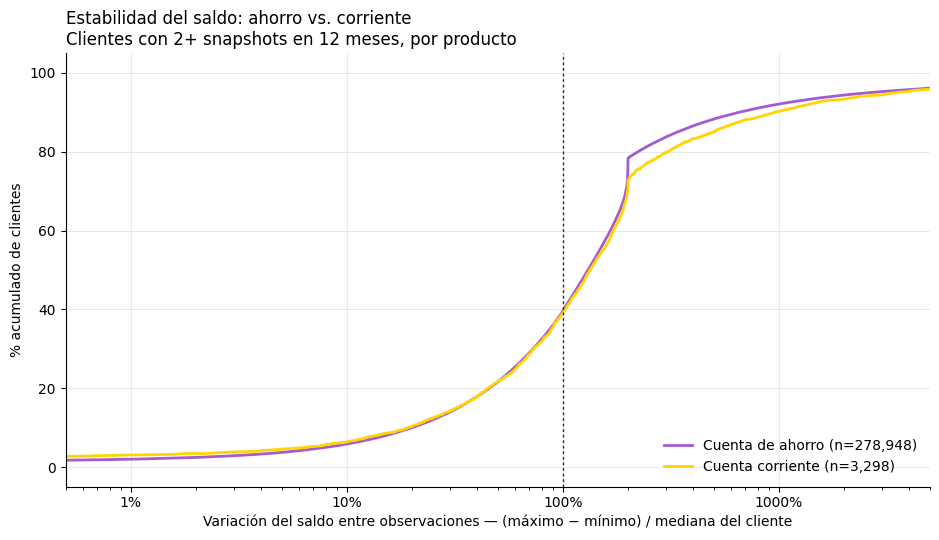

In [ ]:
def rango_relativo_por_producto(df_wide, col_saldo):
    datos = df_wide.dropna(subset=[col_saldo])
    n_snap = datos.groupby("numero_id").size()
    con_2_o_mas = n_snap[n_snap >= 2].index
    sub = datos[datos["numero_id"].isin(con_2_o_mas)]
    stats = sub.groupby("numero_id")[col_saldo].agg(["min", "max", "median"])
    rango = (stats["max"] - stats["min"]) / stats["median"].replace(0, np.nan)
    rango = rango.dropna()
    return rango[rango >= 0]

rango_ahorro = rango_relativo_por_producto(df_aho_cte_wide, "saldo_ahorro")
rango_corriente = rango_relativo_por_producto(df_aho_cte_wide, "saldo_corriente")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
series = [
    (rango_ahorro, "Cuenta de ahorro", PALETA['violeta']),
    (rango_corriente, "Cuenta corriente", PALETA['amarillo']),
]

for rango, etiqueta, color in series:
    valores_ordenados = np.sort(rango.values)
    pct_acumulado = np.arange(1, len(valores_ordenados) + 1) / len(valores_ordenados) * 100
    ax.plot(valores_ordenados, pct_acumulado, color=color, linewidth=2, label=f"{etiqueta} (n={len(rango):,})")

ax.axvline(1.0, color=PALETA['negro'], linewidth=1, linestyle=(0, (2, 2)))
ax.set_xscale("log")
ax.set_xlim(0.005, 50)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.set_xlabel("Variación del saldo entre observaciones — (máximo − mínimo) / mediana del cliente")
ax.set_ylabel("% acumulado de clientes")
ax.set_title(
    "Estabilidad del saldo: ahorro vs. corriente\nClientes con 2+ snapshots en 12 meses, por producto",
    fontsize=12, loc="left"
)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="both", color="#E5E5E5", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


Las dos curvas son prácticamente idénticas. A pesar de que son productos con propósitos distintos (ahorro vs. operación transaccional/sobregiro) y volúmenes de datos muy diferentes, el patrón de volatilidad del cliente es el mismo: en ambos casos, el cliente típico se mueve más del 100% de su propio saldo mediano entre observaciones.

Es evidencia para justificar el mismo tratamiento (resumen_ahorro y resumen_corriente con la misma lógica de mediana/min/max/último/n_snapshots) en las dos columnas.

No se usa el promedio porque tanto saldo_ahorro como saldo_corriente tienen distribuciones fuertemente sesgadas, un promedio se deja arrastrar por el snapshot más extremo que se haya capturado, y como ya se comprobó que el saldo de un mismo cliente varía más del 100% entre observaciones, ese extremo no es un caso raro, es prácticamente la norma. La mediana resuelve eso: representa el nivel típico del cliente sin que un solo dato atípico lo distorsione, que es justo lo que un promedio no puede garantizar aquí. Pero la mediana sola tampoco basta, porque resumir en un único número borra la volatilidad, y ya se demostró que esa volatilidad es comportamiento real del cliente, no ruido a eliminar, por eso se conservan el mínimo y el máximo, que documentan el rango real de movimiento observado. Finalmente, se agrega el último saldo conocido porque la mediana histórica responde "cómo se comporta normalmente este cliente", mientras que el último responde "cuánto tiene disponible hoy", son preguntas distintas y ambas relevantes para decidir a quién priorizar en la App de inversiones, así que ninguna reemplaza a la otra.

In [ ]:
resumen_ahorro = construir_resumen(df_aho_cte_wide, "saldo_ahorro", "ahorro")
resumen_corriente = construir_resumen(df_aho_cte_wide, "saldo_corriente", "corriente")

In [ ]:
resumen_ahorro

,numero_id,saldo_ahorro_mediana_historica,saldo_ahorro_min,saldo_ahorro_max,saldo_ahorro_ultimo,n_snapshots_ahorro,saldo_ahorro_rango_relativo,confianza_historia_ahorro
0,-9223363218022227742,9.100193e+06,8217759.16,9982625.92,9982625.92,2,0.193937,dato_parcial
1,-9223346962119307178,8.432100e+02,781.92,3443.21,781.92,3,3.156141,dato_parcial
2,-9223298745132620006,7.295938e+06,7295937.56,7295937.56,7295937.56,1,0.000000,dato_unico
3,-9223260477860588988,1.294000e+01,0.15,25.73,25.73,2,1.976816,dato_parcial
4,-9223257141299505031,2.791130e+04,27911.30,27911.30,27911.30,1,0.000000,dato_unico
...,...,...,...,...,...,...,...,...
474243,9223189938922631450,2.145800e+02,15.82,413.34,413.34,2,1.852549,dato_parcial
474244,9223247482127794111,3.222337e+05,180007.37,464459.95,464459.95,2,0.882753,dato_parcial
474245,9223271613880707582,1.506015e+06,1198978.99,1813051.76,1198978.99,2,0.407747,dato_parcial
474246,9223331077263849199,1.673477e+06,2281.75,3344673.10,3344673.10,2,1.997273,dato_parcial


In [ ]:
resumen_corriente

,numero_id,saldo_corriente_mediana_historica,saldo_corriente_min,saldo_corriente_max,saldo_corriente_ultimo,n_snapshots_corriente,saldo_corriente_rango_relativo,confianza_historia_corriente
0,-9219781074725433726,-4.939850e+06,-4939849.59,-4939849.59,-4939849.59,1,0.000000,dato_unico
1,-9217083200582439466,1.265155e+03,474.35,2055.96,474.35,2,1.250131,dato_parcial
2,-9213395394509349175,3.224384e+07,6383431.28,58104242.59,6383431.28,2,1.604053,dato_parcial
3,-9212505799957876399,-9.954246e+05,-1023836.59,10360666.22,10360666.22,3,-11.436831,dato_parcial
4,-9211171823082130109,1.023071e+05,102307.15,102307.15,102307.15,1,0.000000,dato_unico
...,...,...,...,...,...,...,...,...
5640,9201090699894893314,2.196840e+05,219684.03,219684.03,219684.03,2,0.000000,dato_parcial
5641,9202701496296407361,1.464655e+03,-8708.62,11637.93,-8708.62,2,13.891701,dato_parcial
5642,9204826980070917179,6.318990e+07,46025470.31,80354323.36,80354323.36,2,0.543265,dato_parcial
5643,9205216860702966046,4.826390e+03,2645.06,7007.72,7007.72,2,0.903918,dato_parcial


In [ ]:
resumen_aho_cte = resumen_ahorro.merge(resumen_corriente, on="numero_id", how="outer")

print(resumen_aho_cte.isnull().sum())

numero_id                                 0
saldo_ahorro_mediana_historica         1471
saldo_ahorro_min                       1471
saldo_ahorro_max                       1471
saldo_ahorro_ultimo                    1471
n_snapshots_ahorro                     1471
saldo_ahorro_rango_relativo            2453
confianza_historia_ahorro              1471
saldo_corriente_mediana_historica    470074
saldo_corriente_min                  470074
saldo_corriente_max                  470074
saldo_corriente_ultimo               470074
n_snapshots_corriente                470074
saldo_corriente_rango_relativo       470099
confianza_historia_corriente         470074
dtype: int64


In [ ]:
# Llenar de 0 los campos NaN
df_aho_cte_wide['saldo_ahorro'] = df_aho_cte_wide['saldo_ahorro'].fillna(0)
df_aho_cte_wide['saldo_corriente'] = df_aho_cte_wide['saldo_corriente'].fillna(0)

In [ ]:
df_aho_cte_wide

,numero_id,año_mes,saldo_ahorro,saldo_corriente
0,-9223363218022227742,2025-06,8217759.16,0.0
1,-9223363218022227742,2026-01,9982625.92,0.0
2,-9223346962119307178,2025-06,3443.21,0.0
3,-9223346962119307178,2025-09,843.21,0.0
4,-9223346962119307178,2026-06,781.92,0.0
...,...,...,...,...
998384,9223271613880707582,2025-12,1813051.76,0.0
998385,9223271613880707582,2026-02,1198978.99,0.0
998386,9223331077263849199,2025-06,2281.75,0.0
998387,9223331077263849199,2026-01,3344673.10,0.0


In [ ]:
cols_a_rellenar = [
    "saldo_ahorro_mediana_historica", "saldo_ahorro_min", "saldo_ahorro_max", "saldo_ahorro_ultimo", "n_snapshots_ahorro",
    "saldo_ahorro_rango_relativo",
    "saldo_corriente_mediana_historica", "saldo_corriente_min", "saldo_corriente_max", "saldo_corriente_ultimo", "n_snapshots_corriente",
    "saldo_corriente_rango_relativo",
]

resumen_aho_cte["tiene_ahorro"] = resumen_aho_cte["n_snapshots_ahorro"].notna().astype(int)
resumen_aho_cte["tiene_corriente"] = resumen_aho_cte["n_snapshots_corriente"].notna().astype(int)

resumen_aho_cte[cols_a_rellenar] = resumen_aho_cte[cols_a_rellenar].fillna(0)

for col in ["confianza_historia_ahorro", "confianza_historia_corriente"]:
    resumen_aho_cte[col] = marcar_no_aplica(resumen_aho_cte[col])


In [ ]:
sobregiro_resumen = (
    df_aho_cte_mensual
    .groupby("numero_id")
    .agg(
        tuvo_sobregiro=("sobregiro", "max"),
        tuvo_sobregiro_atipico=("sobregiro_atipico", "max"),
    )
    .reset_index()
)

resumen_aho_cte = resumen_aho_cte.merge(sobregiro_resumen, on="numero_id", how="left")
resumen_aho_cte[["tuvo_sobregiro", "tuvo_sobregiro_atipico"]] = (
    resumen_aho_cte[["tuvo_sobregiro", "tuvo_sobregiro_atipico"]].fillna(0).astype(int)
)


In [ ]:
resumen_aho_cte

,numero_id,saldo_ahorro_mediana_historica,saldo_ahorro_min,saldo_ahorro_max,saldo_ahorro_ultimo,n_snapshots_ahorro,saldo_ahorro_rango_relativo,confianza_historia_ahorro,saldo_corriente_mediana_historica,saldo_corriente_min,saldo_corriente_max,saldo_corriente_ultimo,n_snapshots_corriente,saldo_corriente_rango_relativo,confianza_historia_corriente,tiene_ahorro,tiene_corriente,tuvo_sobregiro,tuvo_sobregiro_atipico
0,-9223363218022227742,9.100193e+06,8217759.16,9982625.92,9982625.92,2.0,0.193937,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
1,-9223346962119307178,8.432100e+02,781.92,3443.21,781.92,3.0,3.156141,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
2,-9223298745132620006,7.295938e+06,7295937.56,7295937.56,7295937.56,1.0,0.000000,dato_unico,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
3,-9223260477860588988,1.294000e+01,0.15,25.73,25.73,2.0,1.976816,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
4,-9223257141299505031,2.791130e+04,27911.30,27911.30,27911.30,1.0,0.000000,dato_unico,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475714,9223189938922631450,2.145800e+02,15.82,413.34,413.34,2.0,1.852549,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
475715,9223247482127794111,3.222337e+05,180007.37,464459.95,464459.95,2.0,0.882753,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
475716,9223271613880707582,1.506015e+06,1198978.99,1813051.76,1198978.99,2.0,0.407747,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0
475717,9223331077263849199,1.673477e+06,2281.75,3344673.10,3344673.10,2.0,1.997273,dato_parcial,0.0,0.0,0.0,0.0,0.0,0.0,no_aplica,1,0,0,0


| Variable | Qué representa | Para qué sirve en la ABT |
|---|---|---|
| `saldo_ahorro_mediana_historica` | Nivel típico de saldo en cuenta de ahorro, robusto a un dato puntual | Insumo directo del modelo de monto potencial — liquidez disponible candidata a migrar a la App |
| `saldo_corriente_mediana_historica` | Nivel típico de saldo en cuenta corriente, robusto a un dato puntual | Mismo propósito que la anterior, para el segundo producto de liquidez |
| `saldo_ahorro_ultimo` | Última posición de liquidez conocida en ahorro | Estado actual del cliente — relevante para el timing de una campaña |
| `saldo_corriente_ultimo` | Última posición de liquidez conocida en corriente | Mismo propósito que la anterior, para corriente |
| `saldo_ahorro_min` / `saldo_ahorro_max` | Rango real de saldo observado en ahorro | Conserva la volatilidad como señal de comportamiento, no la borra |
| `saldo_corriente_min` / `saldo_corriente_max` | Rango real de saldo observado en corriente | Mismo propósito que el anterior, para corriente |
| `saldo_ahorro_rango_relativo` | Qué tanto se mueve el saldo de ahorro respecto a su nivel típico | Proxy de actividad transaccional del cliente |
| `n_snapshots` / `confianza_historia` | Cuántas observaciones reales respaldan las métricas de ahorro | Trazabilidad — evita tratar igual un dato de 1 observación que uno de 8 |
| `n_snapshots_corriente` | Cuántas observaciones reales respaldan las métricas de corriente | Mismo propósito que `n_snapshots`, para corriente |
| `sobregiro` | Si el saldo del mes fue negativo (cualquier producto) | Señal de uso de cupo / comportamiento de crédito |
| `sobregiro_atipico` | Saldo negativo específicamente en `CUENTA DE AHORRO` | Marca casos anómalos que ameritan revisión, no sobregiro esperado |


## Limpieza tabla crean_bolsillos.db

In [ ]:
df_bolsillos

,fecha,numero_id,producto,saldo,año_mes
0,2026-05-01,1013449549804401435,BOLSILLOS,0.00,2026-05
1,2026-04-01,-1429655475333460263,BOLSILLOS,762189.70,2026-04
2,2026-04-01,-7881360550938175834,BOLSILLOS,761222.85,2026-04
3,2025-08-01,-4886857658013163021,BOLSILLOS,100000.00,2025-08
4,2026-01-01,1547171292443722937,BOLSILLOS,0.00,2026-01
...,...,...,...,...,...
999995,2025-10-01,-4147989453817189354,BOLSILLOS,0.00,2025-10
999996,2025-09-01,-748214362140824892,BOLSILLOS,0.00,2025-09
999997,2026-04-01,5967259449296182379,BOLSILLOS,0.00,2026-04
999998,2026-04-01,-1525077198475398756,BOLSILLOS,250000.00,2026-04


In [ ]:
df_bolsillos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   fecha      1000000 non-null  datetime64[ns]
 1   numero_id  1000000 non-null  object        
 2   producto   1000000 non-null  object        
 3   saldo      1000000 non-null  float64       
 4   año_mes    1000000 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), object(2), period[M](1)
memory usage: 38.1+ MB


In [ ]:
df_bolsillos.isnull().sum()

,0
fecha,0
numero_id,0
producto,0
saldo,0
año_mes,0


In [ ]:
df_bolsillos.duplicated(subset=["fecha", "numero_id", "producto"]).sum()

np.int64(0)

In [ ]:
df_bolsillos['producto'].value_counts()

,count
producto,
BOLSILLOS,1000000


In [ ]:
# Convertir a datetime
df_bolsillos["fecha"] = pd.to_datetime(df_bolsillos["fecha"])
df_bolsillos["año_mes"] = df_bolsillos["fecha"].dt.to_period("M")
df_bolsillos["dia_mes"] = df_bolsillos["fecha"].dt.day

In [ ]:
# Colapso a un registro por numero_id x año_mes, tomando el ultimo saldo del mes
df_bolsillos_mensual = (
    df_bolsillos
    .sort_values("fecha")
    .groupby(["numero_id", "año_mes"], as_index=False)["saldo"]
    .last()
)

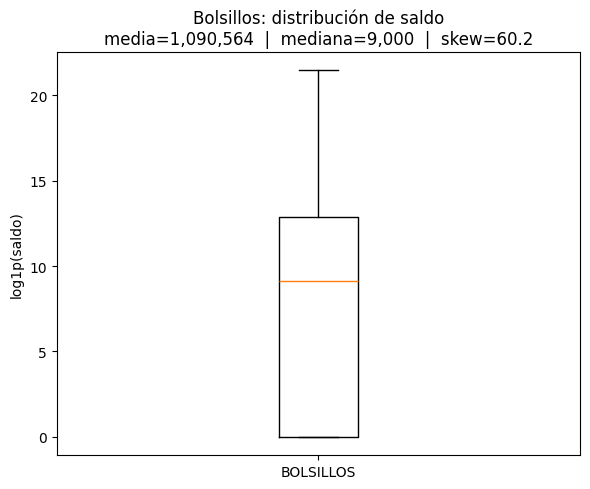

In [ ]:
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.boxplot(np.log1p(df_bolsillos["saldo"]), tick_labels=["BOLSILLOS"])
ax3.set_ylabel("log1p(saldo)")
ax3.set_title(
    "Bolsillos: distribución de saldo\n"
    f"media={df_bolsillos['saldo'].mean():,.0f}  |  "
    f"mediana={df_bolsillos['saldo'].median():,.0f}  |  skew={df_bolsillos['saldo'].skew():.1f}"
)
plt.tight_layout()
plt.show()


La media (1,090,564) es 121 veces más grande que la mediana (9,000),
señal clara de que unos pocos saldos extremadamente altos arrastran el
promedio, mientras la mayoría de clientes mantiene montos modestos,
coherente con el propósito de bolsillos (ahorro por metas de corto
plazo).

In [ ]:
resumen_bolsillos = construir_resumen(df_bolsillos_mensual, "saldo", "bolsillos")

In [ ]:
resumen_bolsillos

,numero_id,saldo_bolsillos_mediana_historica,saldo_bolsillos_min,saldo_bolsillos_max,saldo_bolsillos_ultimo,n_snapshots_bolsillos,saldo_bolsillos_rango_relativo,confianza_historia_bolsillos
0,-1000036548552320712,1750000.000,0.00,1750000.00,0.00,5,1.00000,dato_robusto
1,-1000078413709033561,129805.330,129805.33,129805.33,129805.33,2,0.00000,dato_parcial
2,-1000138464226878655,0.000,0.00,0.00,0.00,4,0.00000,dato_robusto
3,-1000148668513386164,0.000,0.00,0.00,0.00,6,0.00000,dato_robusto
4,-100023096882573577,0.000,0.00,0.00,0.00,6,0.00000,dato_robusto
...,...,...,...,...,...,...,...,...
260709,999650978784694416,0.000,0.00,0.00,0.00,7,0.00000,dato_robusto
260710,999696417188820408,636666.665,0.00,5040000.00,5040000.00,4,7.91623,dato_robusto
260711,999740274247715946,0.000,0.00,0.00,0.00,2,0.00000,dato_parcial
260712,999764162259457840,50000.000,50000.00,50000.00,50000.00,3,0.00000,dato_parcial


**saldo_bolsillos_rango_relativo:**
Mide qué tanto se mueve el saldo del cliente entre sus propias observaciones, relativo a su nivel típico: (máximo − mínimo) / mediana. Un valor de 1.0 significa que la diferencia entre su saldo más alto y más bajo observado es igual a su mediana; valores altos indican un cliente que mueve mucho dinero dentro y fuera del bolsillo, valores bajos indican comportamiento más constante. Se calcula solo para clientes con 2+ snapshots (con 1 solo dato no hay variación que medir). Ojo con el caso borde: si máximo == mínimo (el cliente siempre tuvo el mismo saldo, incluyendo el caso de siempre $0), el resultado debe forzarse a 0 explícitamente — si no, la división por una mediana de 0 da NaN aunque en realidad la respuesta correcta sea "no hubo variación".

**confianza_historia_bolsillos:**
Traduce n_snapshots_bolsillos (cuántas veces se observó al cliente en los 13 meses) a una categoría legible: dato_unico (1 observación), dato_parcial (2-3), dato_robusto (4+). No mide cuánto dinero tiene el cliente ni qué tan "bueno" es el dato — mide cuánta evidencia respalda las demás métricas (mediana histórica, mínimo, máximo, último). Un cliente dato_robusto con saldo bajo no es mejor ni peor que uno dato_unico; simplemente hay más certeza sobre su comportamiento. Recuerda que esta categoría no significa lo mismo entre fuentes — en bolsillos la mayoría de clientes cae en dato_parcial/dato_robusto (solo 7.3% es dato_unico), mientras que en aho_cte el 39.4% es dato_unico — son escalas de densidad distintas aunque los nombres de las categorías sean iguales.

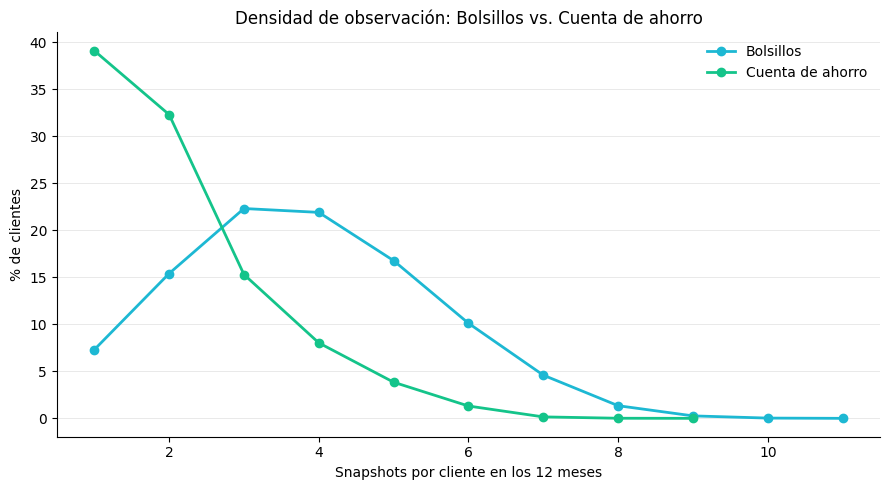

In [ ]:
n_snap_bolsillos = df_bolsillos_mensual.groupby("numero_id").size()
pct_bolsillos = n_snap_bolsillos.value_counts(normalize=True).sort_index() * 100
n_snap_aho = df_aho_cte_wide.dropna(subset=["saldo_ahorro"]).groupby("numero_id").size()
pct_aho = n_snap_aho.value_counts(normalize=True).sort_index() * 100  # calculado igual que para aho_cte

fig4, ax4 = plt.subplots(figsize=(9, 5))
ax4.plot(pct_bolsillos.index, pct_bolsillos.values, "o-", color=PALETA['azul'], linewidth=2, label="Bolsillos")
ax4.plot(pct_aho.index, pct_aho.values, "o-", color=PALETA['verde'], linewidth=2, label="Cuenta de ahorro")
ax4.set_xlabel("Snapshots por cliente en los 12 meses")
ax4.set_ylabel("% de clientes")
ax4.set_title("Densidad de observación: Bolsillos vs. Cuenta de ahorro")
ax4.legend(frameon=False)
ax4.grid(axis="y", color="#E5E5E5", linewidth=0.6)
ax4.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


Esta gráfica muestra cuántas veces "vimos" a cada cliente durante el año. En cuenta de ahorro, la mayoría de clientes solo aparece una vez, es un vistazo aislado. En bolsillos, en cambio, lo normal es verlos entre 3 y 5 veces. Es decir, tenemos más ocasiones para observar el comportamiento real de alguien con su bolsillo que con su cuenta de ahorro, así que no se puede exigir el mismo nivel de certeza a ambos datos.

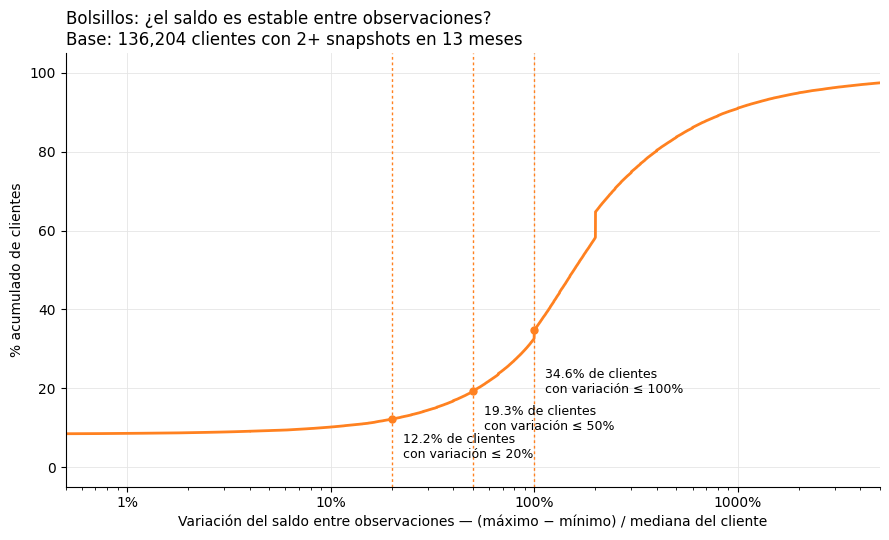

In [ ]:
n_snap_bolsillos = df_bolsillos_mensual.groupby("numero_id").size()

con_2_o_mas = n_snap_bolsillos[n_snap_bolsillos >= 2].index
sub = df_bolsillos_mensual[df_bolsillos_mensual["numero_id"].isin(con_2_o_mas)]
stats = sub.groupby("numero_id")["saldo"].agg(["min", "max", "median"])
stats["rango_relativo"] = (stats["max"] - stats["min"]) / stats["median"].replace(0, np.nan)
rango = stats["rango_relativo"].dropna()
rango = rango[rango >= 0]

valores_ordenados = np.sort(rango.values)
pct_acumulado = np.arange(1, len(valores_ordenados) + 1) / len(valores_ordenados) * 100

fig5, ax5 = plt.subplots(figsize=(9, 5.5))
ax5.plot(valores_ordenados, pct_acumulado, color=PALETA['naranja'], linewidth=2)
for umbral, etiqueta in [(0.20, "20%"), (0.50, "50%"), (1.00, "100%")]:
    pct_en_umbral = (rango <= umbral).mean() * 100
    ax5.axvline(umbral, color=PALETA['naranja'], linewidth=1, linestyle=(0, (2, 2)))
    ax5.plot([umbral], [pct_en_umbral], "o", color=PALETA['naranja'], markersize=5, zorder=5)
    ax5.annotate(
        f"{pct_en_umbral:.1f}% de clientes\ncon variación ≤ {etiqueta}",
        xy=(umbral, pct_en_umbral), xytext=(8, -28 if umbral < 1 else -45),
        textcoords="offset points", fontsize=9,
    )
ax5.set_xscale("log")
ax5.set_xlim(0.005, 50)
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax5.set_xlabel("Variación del saldo entre observaciones — (máximo − mínimo) / mediana del cliente")
ax5.set_ylabel("% acumulado de clientes")
ax5.set_title(
    "Bolsillos: ¿el saldo es estable entre observaciones?\n"
    f"Base: {len(rango):,} clientes con 2+ snapshots en 13 meses", fontsize=12, loc="left"
)
ax5.grid(axis="both", color="#E5E5E5", linewidth=0.6)
ax5.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


Esta gráfica responde una pregunta simple: cuando volvemos a mirar el saldo de un cliente, ¿sigue siendo parecido al que tenía antes? La respuesta es que casi nunca: solo 1 de cada 5 clientes mantiene un saldo relativamente parecido entre una revisión y otra (variación de 50% o menos); para la mayoría, el monto cambia bastante de una vez a la siguiente. Esto tiene sentido con el propósito del producto — un bolsillo es dinero que se mueve activamente hacia una meta, no un ahorro que se queda quieto, y confirma que no conviene resumir el comportamiento de un cliente en un solo número fijo, porque ese número casi nunca cuenta toda la historia.

## Limpieza tabla crean_fiducuenta.db

Fiducuenta es un producto fiduciario de administración/inversión, no transaccional, tiene sentido que el saldo se mueva menos entre observaciones que en una cuenta de ahorro o un bolsillo de metas. Es información consistente con la naturaleza del producto, no una anomalía a corregir.

In [ ]:
df_crean_fiducuenta

,fecha,numero_id,producto,saldo,año_mes
0,2025-09-01,-2165011641475171977,FIDUCUENTA,19337.21,2025-09
1,2025-08-01,-2661850999936757122,FIDUCUENTA,7540113.82,2025-08
2,2026-06-01,7030715403446493978,FIDUCUENTA,2308.21,2026-06
3,2026-05-01,7720175993936919159,FIDUCUENTA,2818.81,2026-05
4,2025-11-01,-6374737054833898392,FIDUCUENTA,633685.45,2025-11
...,...,...,...,...,...
999995,2025-10-01,-6198252921306236892,FIDUCUENTA,1554.20,2025-10
999996,2026-02-01,-5656580597524108061,FIDUCUENTA,81629.70,2026-02
999997,2026-02-01,-3838366380088592821,FIDUCUENTA,847962.13,2026-02
999998,2025-11-01,2928135275105768767,FIDUCUENTA,6294.02,2025-11


In [ ]:
df_crean_fiducuenta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   fecha      1000000 non-null  datetime64[ns]
 1   numero_id  1000000 non-null  object        
 2   producto   1000000 non-null  object        
 3   saldo      1000000 non-null  float64       
 4   año_mes    1000000 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), object(2), period[M](1)
memory usage: 38.1+ MB


In [ ]:
df_crean_fiducuenta.isnull().sum()

,0
fecha,0
numero_id,0
producto,0
saldo,0
año_mes,0


In [ ]:
df_crean_fiducuenta.duplicated(subset=["fecha", "numero_id", "producto"]).sum()

np.int64(0)

In [ ]:
df_crean_fiducuenta['producto'].value_counts()

,count
producto,
FIDUCUENTA,1000000


In [ ]:
# Convertir a datetime
df_crean_fiducuenta["fecha"] = pd.to_datetime(df_crean_fiducuenta["fecha"])
df_crean_fiducuenta["año_mes"] = df_crean_fiducuenta["fecha"].dt.to_period("M")
df_crean_fiducuenta["dia_mes"] = df_crean_fiducuenta["fecha"].dt.day

In [ ]:
df_fiducuenta_mensual = (
    df_crean_fiducuenta
    .sort_values("fecha")
    .groupby(["numero_id", "año_mes"], as_index=False)["saldo"]
    .last()
)

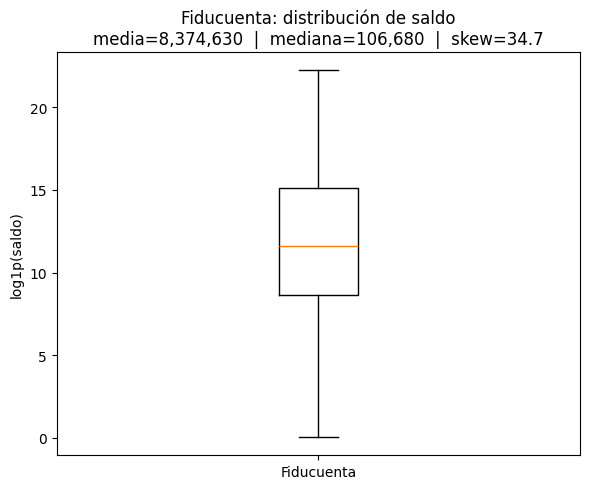

In [ ]:
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.boxplot(np.log1p(df_crean_fiducuenta["saldo"]), tick_labels=["Fiducuenta"])
ax3.set_ylabel("log1p(saldo)")
ax3.set_title(
    "Fiducuenta: distribución de saldo\n"
    f"media={df_crean_fiducuenta['saldo'].mean():,.0f}  |  "
    f"mediana={df_crean_fiducuenta['saldo'].median():,.0f}  |  skew={df_crean_fiducuenta['saldo'].skew():.1f}"
)
plt.tight_layout()
plt.show()

Fiducuenta muestra una diferencia muy marcada entre el saldo promedio y el saldo típico: mientras el promedio ronda los 8.37 millones, la mitad de las cuentas tiene un saldo por debajo de apenas 106,680. Esto indica que un grupo reducido de cuentas con montos muy altos está elevando el promedio general, sin que esto refleje la realidad de la mayoría de los clientes. El indicador de asimetría, cercano a 35, confirma esta distorsión: hay unas pocas cuentas con saldos extraordinariamente grandes que se alejan bastante del comportamiento común.

En la gráfica, la caja central concentra a la mayoría de las cuentas en un rango de saldo bajo, y la línea que se extiende hacia arriba muestra que existen casos aislados con saldos mucho mayores, hasta llegar a valores excepcionalmente altos. En resumen, la cartera de Fiducuenta está compuesta principalmente por saldos modestos, con unas pocas cuentas grandes que no representan el comportamiento habitual del resto.

In [ ]:
resumen_fiducuenta = construir_resumen(df_fiducuenta_mensual, "saldo", "fiducuenta")

In [ ]:
resumen_fiducuenta

,numero_id,saldo_fiducuenta_mediana_historica,saldo_fiducuenta_min,saldo_fiducuenta_max,saldo_fiducuenta_ultimo,n_snapshots_fiducuenta,saldo_fiducuenta_rango_relativo,confianza_historia_fiducuenta
0,-1000078413709033561,4.847910e+03,4699.10,4940.84,4940.84,4,0.049865,dato_robusto
1,-1000148668513386164,3.463955e+06,1134367.64,7141918.76,6292699.93,6,1.734304,dato_robusto
2,-100023096882573577,1.554162e+06,4004.49,5137361.40,5137361.40,6,3.302974,dato_robusto
3,-1000314687530149526,8.114989e+05,811498.94,811498.94,811498.94,1,0.000000,dato_unico
4,-1000679619218374130,7.998750e+02,771.31,829.67,829.67,6,0.072961,dato_robusto
...,...,...,...,...,...,...,...,...
181016,999488790808254012,3.543732e+07,33956592.90,36525796.22,36525796.22,7,0.072500,dato_robusto
181017,999507621478105881,7.080900e+02,682.03,201617.78,3984.26,9,283.771484,dato_robusto
181018,999599413783425049,4.024648e+04,38911.47,41855.56,41855.56,6,0.073151,dato_robusto
181019,999696417188820408,7.316710e+03,7163.78,7603.67,7603.67,7,0.060121,dato_robusto


## Limpieza tabla crean_inv_virtual_cdt.db

CDT e Inversión Virtual son productos de inversión con reporte de saldo más disciplinado (mensual real, no solo primera semana) y montos mínimos altos — coherente con que sean compromisos de capital, no cuentas transaccionales de uso diario. Esto significa que aquí sí se puede confiar en una noción real de "historial mensual", a diferencia de las 3 fuentes anteriores.

In [ ]:
df_crean_inv_virtual_cdt

,fecha,numero_id,producto,saldo,año_mes
0,2025-06-01,-6228143491694978166,INVERSIóN VIRTUAL,15000000.00,2025-06
1,2025-08-26,4123427955016713068,INVERSIóN VIRTUAL,500000.00,2025-08
2,2025-06-10,-6813311859168202310,INVERSIóN VIRTUAL,62522900.00,2025-06
3,2025-12-01,-1182476400737234276,INVERSIóN VIRTUAL,20627000.00,2025-12
4,2026-03-01,-6751564772676490392,CDT,10025000.00,2026-03
...,...,...,...,...,...
994172,2025-12-01,1186570448487311838,CDT,8003506.37,2025-12
994173,2025-09-01,-5183800770683427522,INVERSIóN VIRTUAL,500000.00,2025-09
994174,2026-01-01,-7143219857331528329,CDT,7500000.00,2026-01
994175,2025-12-01,-4477088580332108807,INVERSIóN VIRTUAL,4500000.00,2025-12


In [ ]:
df_crean_inv_virtual_cdt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994177 entries, 0 to 994176
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   fecha      994177 non-null  datetime64[ns]
 1   numero_id  994177 non-null  object        
 2   producto   994177 non-null  object        
 3   saldo      994177 non-null  float64       
 4   año_mes    994177 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), object(2), period[M](1)
memory usage: 37.9+ MB


In [ ]:
df_crean_inv_virtual_cdt.isnull().sum()

,0
fecha,0
numero_id,0
producto,0
saldo,0
año_mes,0


In [ ]:
df_crean_inv_virtual_cdt.duplicated(subset=["fecha", "numero_id", "producto"]).sum()

np.int64(0)

In [ ]:
df_crean_inv_virtual_cdt['producto'].value_counts()

,count
producto,
INVERSIóN VIRTUAL,678038
CDT,316139


In [ ]:
df_crean_inv_virtual_cdt['producto'] = df_crean_inv_virtual_cdt['producto'].str.upper()

In [ ]:
df_crean_inv_virtual_cdt['producto'].value_counts()

,count
producto,
INVERSIÓN VIRTUAL,678038
CDT,316139


In [ ]:
df_crean_inv_virtual_cdt["fecha"] = pd.to_datetime(df_crean_inv_virtual_cdt["fecha"])
df_crean_inv_virtual_cdt["dia_mes"] = df_crean_inv_virtual_cdt["fecha"].dt.day
df_crean_inv_virtual_cdt["año_mes"] = df_crean_inv_virtual_cdt["fecha"].dt.to_period("M")

In [ ]:
df_inv_virtual_cdt_mensual = (
    df_crean_inv_virtual_cdt
    .sort_values("fecha")
    .groupby(["numero_id", "año_mes", "producto"], as_index=False)
    .last()
)

In [ ]:
df_inv_virtual_cdt_wide = df_inv_virtual_cdt_mensual.pivot_table(
    index=["numero_id", "año_mes"],
    columns="producto",
    values="saldo"
).reset_index()

df_inv_virtual_cdt_wide.columns.name = None
df_inv_virtual_cdt_wide = df_inv_virtual_cdt_wide.rename(columns={
    "CDT": "saldo_cdt",
    "INVERSIÓN VIRTUAL": "saldo_inversion_virtual",
})

In [ ]:
df_inv_virtual_cdt_wide

,numero_id,año_mes,saldo_cdt,saldo_inversion_virtual
0,-1000078413709033561,2025-06,NaN,10000000.0
1,-1000078413709033561,2025-07,NaN,10000000.0
2,-100023096882573577,2025-09,NaN,1000000.0
3,-100023096882573577,2025-10,NaN,1000000.0
4,-100023096882573577,2025-11,NaN,1000000.0
...,...,...,...,...
769682,999740274247715946,2025-08,NaN,15000000.0
769683,999740274247715946,2025-09,NaN,20000000.0
769684,999740274247715946,2025-10,NaN,20000000.0
769685,999740274247715946,2025-11,NaN,20000000.0


In [ ]:
def pct_panel_completo(sub, col_id="numero_id"):
    n_snap = sub.groupby(col_id).size()
    return (n_snap == n_snap.max()).mean() * 100

cdt_obs = df_inv_virtual_cdt_mensual[df_inv_virtual_cdt_mensual["producto"] == "CDT"].sort_values(["numero_id", "año_mes"])
iv_obs = df_inv_virtual_cdt_mensual[df_inv_virtual_cdt_mensual["producto"] == "INVERSIÓN VIRTUAL"].sort_values(["numero_id", "año_mes"])

densidad = {
    "Bolsillos": pct_panel_completo(df_bolsillos_mensual),
    "Ahorro": pct_panel_completo(df_aho_cte_wide.dropna(subset=["saldo_ahorro"])),
    "Corriente": pct_panel_completo(df_aho_cte_wide.dropna(subset=["saldo_corriente"])),
    "Inversión\nVirtual": pct_panel_completo(iv_obs),
    "CDT": pct_panel_completo(cdt_obs),
}

def calcular_pendiente(grupo):
    if len(grupo) < 3:
        return np.nan
    x = np.arange(len(grupo))
    y = grupo["saldo"].values
    return np.polyfit(x, y, 1)[0]

In [ ]:
pendientes_cdt = cdt_obs.groupby("numero_id").apply(calcular_pendiente, include_groups=False)

# se normaliza por la mediana de cada cliente para poder comparar clientes de distinto tamaño de saldo
medianas_cdt = cdt_obs.groupby("numero_id")["saldo"].median()
pendiente_normalizada = (pendientes_cdt / medianas_cdt.reindex(pendientes_cdt.index)) * 100
pendiente_normalizada = pendiente_normalizada.replace([np.inf, -np.inf], np.nan).dropna().clip(-20, 20)

pct_pos = (pendiente_normalizada > 0.5).mean() * 100
pct_neg = (pendiente_normalizada < -0.5).mean() * 100
pct_flat = 100 - pct_pos - pct_neg

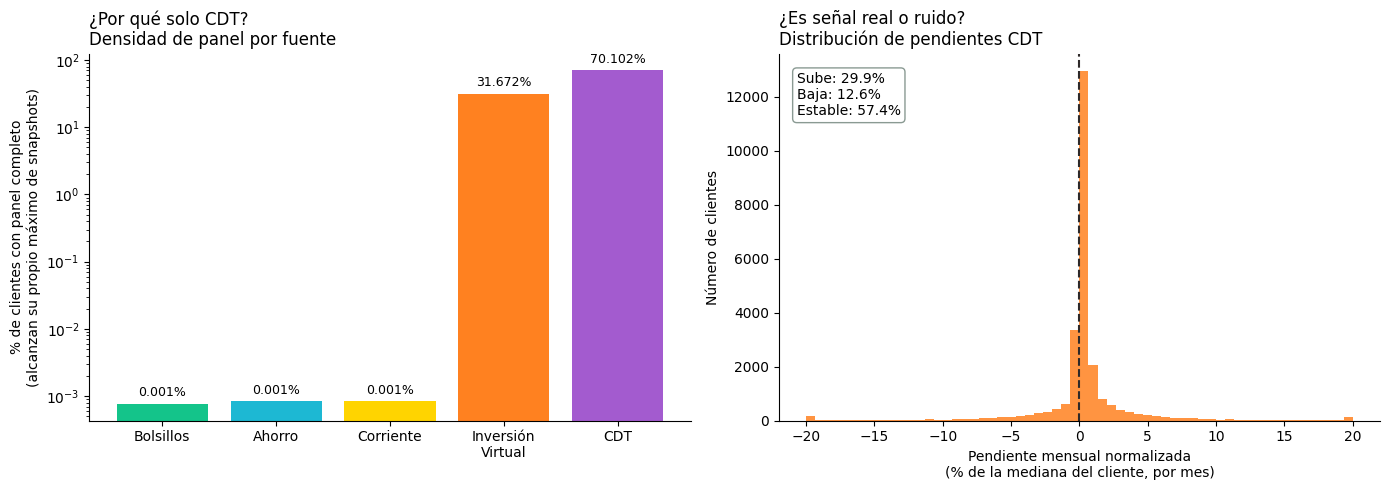

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bars = ax1.bar(densidad.keys(), densidad.values(), color=[PALETA['verde'], PALETA['azul'], PALETA['amarillo'], PALETA['naranja'], PALETA['violeta']])
ax1.set_yscale("log")
ax1.set_ylabel("% de clientes con panel completo\n(alcanzan su propio máximo de snapshots)")
ax1.set_title("¿Por qué solo CDT?\nDensidad de panel por fuente", fontsize=12, loc="left")
for bar, v in zip(bars, densidad.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, v * 1.3, f"{v:.3f}%", ha="center", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

ax2 = axes[1]
ax2.hist(pendiente_normalizada, bins=60, color=PALETA['naranja'], alpha=0.85)
ax2.axvline(0, color=PALETA['negro'], linewidth=1.5, linestyle="--")
ax2.set_xlabel("Pendiente mensual normalizada\n(% de la mediana del cliente, por mes)")
ax2.set_ylabel("Número de clientes")
ax2.set_title("¿Es señal real o ruido?\nDistribución de pendientes CDT", fontsize=12, loc="left")
ax2.text(0.03, 0.95, f"Sube: {pct_pos:.1f}%\nBaja: {pct_neg:.1f}%\nEstable: {pct_flat:.1f}%",
          transform=ax2.transAxes, va="top", fontsize=10,
          bbox=dict(boxstyle="round", facecolor="white", edgecolor="#8A9A93"))
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Por qué la pendiente (tendencia) solo se calcula para CDT:**

Calcular una pendiente confiable requiere varias observaciones por
cliente a lo largo del tiempo, no un dato suelto. El panel izquierdo
muestra qué tan denso es el historial de cada producto: en bolsillos,
ahorro y corriente, prácticamente ningún cliente (0.001%) alcanza su
propio máximo de snapshots — la mayoría solo aparece una o dos veces, no
hay suficiente panel para trazar una línea de tendencia con sentido. CDT
es la excepción clara: 70.1% de sus clientes sí tienen panel completo
(inversión virtual queda a la mitad, 31.7%). Por eso la pendiente se
construye solo para CDT — en los demás productos sería ajustar una recta
sobre 1-2 puntos, puro ruido, no señal.

Pero tener suficientes datos no garantiza que la pendiente signifique
algo real — el panel derecho responde esa segunda pregunta. La
distribución de pendientes normalizadas (% de cambio mensual respecto a
la mediana propia del cliente) no es plana ni aleatoria: se concentra
cerca de cero (57.4% estable) pero con colas interpretables a cada lado
(29.9% en tendencia de subida, 12.6% en bajada). Ese patrón —mayoría
estable, minorías coherentes subiendo o bajando— es la evidencia de que
la pendiente captura comportamiento real de los clientes, no artefactos
del cálculo.


In [ ]:
resumen_cdt = construir_resumen(df_inv_virtual_cdt_wide, "saldo_cdt", "cdt")
resumen_inversion_virtual = construir_resumen(df_inv_virtual_cdt_wide, "saldo_inversion_virtual", "inversion_virtual")

print(resumen_cdt.shape, resumen_inversion_virtual.shape)
resumen_cdt.head()

(26273, 8) (61215, 8)


,numero_id,saldo_cdt_mediana_historica,saldo_cdt_min,saldo_cdt_max,saldo_cdt_ultimo,n_snapshots_cdt,saldo_cdt_rango_relativo,confianza_historia_cdt
0,-1000287200153483778,40000000.00,40000000.00,40000000.00,40000000.00,2,0.000000,dato_parcial
1,-1001053817557236674,12487438.45,12004788.33,12957725.37,12957725.37,13,0.076312,dato_robusto
2,-1001736211507010669,30000000.00,30000000.00,30000000.00,30000000.00,2,0.000000,dato_parcial
3,-1002561516783808856,4500000.00,4500000.00,4500000.00,4500000.00,13,0.000000,dato_robusto
4,-1003285618524604404,2275740.17,2192893.01,2359550.04,2359550.04,13,0.073232,dato_robusto


In [ ]:
resumen_cdt

,numero_id,saldo_cdt_mediana_historica,saldo_cdt_min,saldo_cdt_max,saldo_cdt_ultimo,n_snapshots_cdt,saldo_cdt_rango_relativo,confianza_historia_cdt
0,-1000287200153483778,40000000.00,40000000.00,40000000.00,40000000.00,2,0.000000,dato_parcial
1,-1001053817557236674,12487438.45,12004788.33,12957725.37,12957725.37,13,0.076312,dato_robusto
2,-1001736211507010669,30000000.00,30000000.00,30000000.00,30000000.00,2,0.000000,dato_parcial
3,-1002561516783808856,4500000.00,4500000.00,4500000.00,4500000.00,13,0.000000,dato_robusto
4,-1003285618524604404,2275740.17,2192893.01,2359550.04,2359550.04,13,0.073232,dato_robusto
...,...,...,...,...,...,...,...,...
26268,998810591996322022,9000000.00,9000000.00,9000000.00,9000000.00,6,0.000000,dato_robusto
26269,998864616656229605,6798868.41,6798868.41,6798868.41,6798868.41,13,0.000000,dato_robusto
26270,998955571704778427,50000000.00,50000000.00,50000000.00,50000000.00,13,0.000000,dato_robusto
26271,999078298972082213,10604464.80,10604464.80,10604464.80,10604464.80,13,0.000000,dato_robusto


In [ ]:
resumen_inversion_virtual

,numero_id,saldo_inversion_virtual_mediana_historica,saldo_inversion_virtual_min,saldo_inversion_virtual_max,saldo_inversion_virtual_ultimo,n_snapshots_inversion_virtual,saldo_inversion_virtual_rango_relativo,confianza_historia_inversion_virtual
0,-1000078413709033561,10000000.0,10000000.0,10000000.0,10000000.0,2,0.000000,dato_parcial
1,-100023096882573577,1000000.0,1000000.0,1000000.0,1000000.0,7,0.000000,dato_robusto
2,-1000314687530149526,500000.0,500000.0,500000.0,500000.0,9,0.000000,dato_robusto
3,-1001705771655542744,30000000.0,30000000.0,30000000.0,30000000.0,8,0.000000,dato_robusto
4,-1002016113972521899,5000000.0,3000000.0,5000000.0,5000000.0,11,0.400000,dato_robusto
...,...,...,...,...,...,...,...,...
61210,998810591996322022,3383000.0,3383000.0,3383000.0,3383000.0,1,0.000000,dato_unico
61211,999006285453706952,50000000.0,25000000.0,100000000.0,40000000.0,13,1.500000,dato_robusto
61212,999129380280770100,40500000.0,36000000.0,57000000.0,57000000.0,6,0.518519,dato_robusto
61213,999488790808254012,85000000.0,85000000.0,85000000.0,85000000.0,3,0.000000,dato_parcial


In [ ]:
cdt_obs = df_inv_virtual_cdt_mensual[df_inv_virtual_cdt_mensual["producto"] == "CDT"].sort_values(["numero_id", "año_mes"])

def calcular_pendiente(grupo):
    if len(grupo) < 3:
        return np.nan
    x = np.arange(len(grupo))
    y = grupo["saldo"].values
    return np.polyfit(x, y, 1)[0]

pendientes_cdt = cdt_obs.groupby("numero_id").apply(calcular_pendiente, include_groups=False)
resumen_cdt["saldo_cdt_pendiente_mensual"] = resumen_cdt["numero_id"].map(pendientes_cdt)

print(f"Clientes con pendiente calculada: {resumen_cdt['saldo_cdt_pendiente_mensual'].notna().sum():,} de {len(resumen_cdt):,}")


Clientes con pendiente calculada: 24,946 de 26,273


In [ ]:
resumen_inv_virtual_cdt = resumen_cdt.merge(resumen_inversion_virtual, on="numero_id", how="outer")

cols_a_rellenar = [
    "saldo_cdt_mediana_historica", "saldo_cdt_min", "saldo_cdt_max", "saldo_cdt_ultimo",
    "n_snapshots_cdt", "saldo_cdt_rango_relativo",
    "saldo_inversion_virtual_mediana_historica", "saldo_inversion_virtual_min", "saldo_inversion_virtual_max",
    "saldo_inversion_virtual_ultimo", "n_snapshots_inversion_virtual", "saldo_inversion_virtual_rango_relativo",
]

resumen_inv_virtual_cdt["tiene_cdt"] = resumen_inv_virtual_cdt["n_snapshots_cdt"].notna().astype(int)
resumen_inv_virtual_cdt["tiene_inv_virtual"] = resumen_inv_virtual_cdt["n_snapshots_inversion_virtual"].notna().astype(int)

resumen_inv_virtual_cdt[cols_a_rellenar] = resumen_inv_virtual_cdt[cols_a_rellenar].fillna(0)


for col in ["confianza_historia_cdt", "confianza_historia_inversion_virtual"]:
    resumen_inv_virtual_cdt[col] = marcar_no_aplica(resumen_inv_virtual_cdt[col])

print(resumen_inv_virtual_cdt.shape)
resumen_inv_virtual_cdt.isnull().sum()

(84104, 18)


,0
numero_id,0
saldo_cdt_mediana_historica,0
saldo_cdt_min,0
saldo_cdt_max,0
saldo_cdt_ultimo,0
n_snapshots_cdt,0
saldo_cdt_rango_relativo,0
confianza_historia_cdt,0
saldo_cdt_pendiente_mensual,59158
saldo_inversion_virtual_mediana_historica,0


In [ ]:
sin_cdt = resumen_inv_virtual_cdt["tiene_cdt"] == 0
con_cdt_pocos_snapshots = (resumen_inv_virtual_cdt["tiene_cdt"] == 1) & (resumen_inv_virtual_cdt["saldo_cdt_pendiente_mensual"].isna())

print(f"Sin CDT (no aplica):                        {sin_cdt.sum():,}")
print(f"Con CDT pero <3 snapshots (no calculable):  {con_cdt_pocos_snapshots.sum():,}")
print(f"Total (debe dar 59,158):                    {sin_cdt.sum() + con_cdt_pocos_snapshots.sum():,}")

Sin CDT (no aplica):                        57,831
Con CDT pero <3 snapshots (no calculable):  1,327
Total (debe dar 59,158):                    59,158


In [ ]:
resumen_inv_virtual_cdt

,numero_id,saldo_cdt_mediana_historica,saldo_cdt_min,saldo_cdt_max,saldo_cdt_ultimo,n_snapshots_cdt,saldo_cdt_rango_relativo,confianza_historia_cdt,saldo_cdt_pendiente_mensual,saldo_inversion_virtual_mediana_historica,saldo_inversion_virtual_min,saldo_inversion_virtual_max,saldo_inversion_virtual_ultimo,n_snapshots_inversion_virtual,saldo_inversion_virtual_rango_relativo,confianza_historia_inversion_virtual,tiene_cdt,tiene_inv_virtual
0,-1000078413709033561,0.00,0.00,0.00,0.00,0.0,0.000000,no_aplica,NaN,10000000.0,10000000.0,10000000.0,10000000.0,2.0,0.000000,dato_parcial,0,1
1,-100023096882573577,0.00,0.00,0.00,0.00,0.0,0.000000,no_aplica,NaN,1000000.0,1000000.0,1000000.0,1000000.0,7.0,0.000000,dato_robusto,0,1
2,-1000287200153483778,40000000.00,40000000.00,40000000.00,40000000.00,2.0,0.000000,dato_parcial,NaN,0.0,0.0,0.0,0.0,0.0,0.000000,no_aplica,1,0
3,-1000314687530149526,0.00,0.00,0.00,0.00,0.0,0.000000,no_aplica,NaN,500000.0,500000.0,500000.0,500000.0,9.0,0.000000,dato_robusto,0,1
4,-1001053817557236674,12487438.45,12004788.33,12957725.37,12957725.37,13.0,0.076312,dato_robusto,7.119436e+04,0.0,0.0,0.0,0.0,0.0,0.000000,no_aplica,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84099,999078298972082213,10604464.80,10604464.80,10604464.80,10604464.80,13.0,0.000000,dato_robusto,1.487740e-10,0.0,0.0,0.0,0.0,0.0,0.000000,no_aplica,1,0
84100,999129380280770100,0.00,0.00,0.00,0.00,0.0,0.000000,no_aplica,NaN,40500000.0,36000000.0,57000000.0,57000000.0,6.0,0.518519,dato_robusto,0,1
84101,999326453731766637,15000000.00,15000000.00,15000000.00,15000000.00,10.0,0.000000,dato_robusto,3.817952e-10,0.0,0.0,0.0,0.0,0.0,0.000000,no_aplica,1,0
84102,999488790808254012,0.00,0.00,0.00,0.00,0.0,0.000000,no_aplica,NaN,85000000.0,85000000.0,85000000.0,85000000.0,3.0,0.000000,dato_parcial,0,1


In [ ]:
# Rellenar de ceros los valores NaN de saldo_cdt y saldo_inversion_virtual
df_inv_virtual_cdt_wide['saldo_cdt'] = df_inv_virtual_cdt_wide['saldo_cdt'].fillna(0)
df_inv_virtual_cdt_wide['saldo_inversion_virtual'] = df_inv_virtual_cdt_wide['saldo_inversion_virtual'].fillna(0)

## Limpieza tabla estimador_ing.db

In [ ]:
df_estimador_ing

,numero_id,producto,estimador_ingreso,tiene_estimador_ingreso,estimador_ingreso_wz
0,8482174354453385212,ESTIMADOR INGRESO,4853570.31,1,4.853570e+06
1,8831305677363912137,ESTIMADOR INGRESO,1749148.95,1,1.749149e+06
2,8289414305330255763,ESTIMADOR INGRESO,1542841.12,1,1.542841e+06
3,5066284055348912520,ESTIMADOR INGRESO,2889280.32,1,2.889280e+06
4,4208199011104756958,ESTIMADOR INGRESO,1742505.76,1,1.742506e+06
...,...,...,...,...,...
745787,-8239268707335970490,ESTIMADOR INGRESO,1916278.92,1,1.916279e+06
745788,-5308010162155951262,ESTIMADOR INGRESO,7326112.94,1,7.326113e+06
745789,-5188817506908614723,ESTIMADOR INGRESO,6995533.93,1,6.995534e+06
745790,7379795233034940074,ESTIMADOR INGRESO,5005649.49,1,5.005649e+06


In [ ]:
df_estimador_ing.isnull().sum()

,0
numero_id,0
producto,0
estimador_ingreso,0
tiene_estimador_ingreso,0
estimador_ingreso_wz,0


In [ ]:
df_estimador_ing.duplicated(subset=["numero_id"]).sum()

np.int64(0)

In [ ]:
df_estimador_ing['producto'].value_counts()

,count
producto,
ESTIMADOR INGRESO,745792


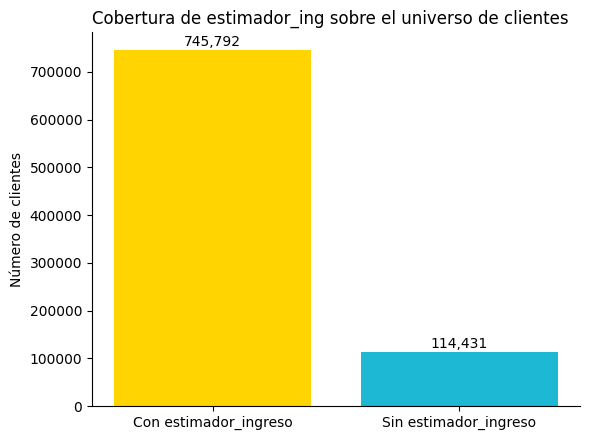

In [ ]:
universo = set(df_clientes["numero_id"])
con_estimador = set(df_estimador_ing["numero_id"])
n_con, n_sin = len(con_estimador), len(universo - con_estimador)

fig1, ax1 = plt.subplots(figsize=(6, 4.5))
ax1.bar(["Con estimador_ingreso", "Sin estimador_ingreso"], [n_con, n_sin], color=[PALETA['amarillo'], PALETA['azul']])
for i, v in enumerate([n_con, n_sin]):
    ax1.text(i, v + 8000, f"{v:,}", ha="center", fontsize=10)
ax1.set_title("Cobertura de estimador_ing sobre el universo de clientes", fontsize=12, loc="left")
ax1.set_ylabel("Número de clientes")
ax1.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

114,431 clientes (13.3%) no tienen estimador_ingreso — necesitará su propio tiene_estimador_ingreso al hacer el merge a la ABT, igual que las demás fuentes.

### Construcción final de columnas para la ABT

In [ ]:
df_estimador_ing["tiene_estimador_ingreso"] = 1  # por construcción, todo registro en esta tabla lo tiene

In [ ]:
# Winsorización al P99, igual criterio que las financieras de clientes (columna paralela, no destructiva)
p99 = df_estimador_ing["estimador_ingreso"].quantile(0.99)
df_estimador_ing["estimador_ingreso_wz"] = df_estimador_ing["estimador_ingreso"].clip(upper=p99)

In [ ]:
# brecha solo donde el denominador es confiable
df_clientes["ingresos_mensuales_wz"] = df_clientes["ingresos_mensuales"].clip(
    upper=df_clientes["ingresos_mensuales"].quantile(0.99)
)
resumen_estimador = df_clientes[["numero_id", "ingresos_mensuales", "ingresos_mensuales_wz"]].merge(
    df_estimador_ing[["numero_id", "estimador_ingreso", "estimador_ingreso_wz", "tiene_estimador_ingreso"]],
    on="numero_id", how="left"
)

In [ ]:
resumen_estimador["tiene_estimador_ingreso"] = resumen_estimador["tiene_estimador_ingreso"].fillna(0).astype(int)

In [ ]:
denominador_valido = resumen_estimador["ingresos_mensuales_wz"] >= 1000
resumen_estimador["brecha_ingreso_absoluta"] = resumen_estimador["estimador_ingreso"] - resumen_estimador["ingresos_mensuales_wz"]
resumen_estimador.loc[denominador_valido, "brecha_ingreso_pct"] = (
    resumen_estimador.loc[denominador_valido, "brecha_ingreso_absoluta"] / resumen_estimador.loc[denominador_valido, "ingresos_mensuales_wz"]
)

In [ ]:
resumen_estimador

,numero_id,ingresos_mensuales,ingresos_mensuales_wz,estimador_ingreso,estimador_ingreso_wz,tiene_estimador_ingreso,brecha_ingreso_absoluta,brecha_ingreso_pct
0,8805210490649048784,29239444.0,22758238.44,NaN,NaN,0,NaN,NaN
1,-5723572980375902369,31024544.0,22758238.44,NaN,NaN,0,NaN,NaN
2,-8245474570363424359,2834000.0,2834000.00,NaN,NaN,0,NaN,NaN
3,-7840506796880772723,28035850.0,22758238.44,NaN,NaN,0,NaN,NaN
4,5309731180094827430,3846205.0,3846205.00,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...
860218,5882320376089669583,5436883.0,5436883.00,5707416.22,5707416.22,1,270533.22,0.049759
860219,6034010744462256034,7143835.0,7143835.00,1423500.00,1423500.00,1,-5720335.00,-0.800737
860220,3918722977197857898,7800000.0,7800000.00,NaN,NaN,0,NaN,NaN
860221,-8439226781033547229,7521978.0,7521978.00,7226462.34,7226462.34,1,-295515.66,-0.039287


In [ ]:
brecha_valida = resumen_estimador["brecha_ingreso_pct"].dropna()
print(brecha_valida.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

for umbral in [0.10, 0.15, 0.20, 0.25, 0.30]:
    pct_dentro = ((brecha_valida >= -umbral) & (brecha_valida <= umbral)).mean() * 100
    print(f"dentro de +/-{umbral*100:.0f}%: {pct_dentro:.1f}% de clientes")

count    742331.000000
mean          0.542358
std          22.034121
min          -0.988997
10%          -0.259149
25%          -0.056905
50%           0.095215
75%           0.429695
90%           0.869697
max        5657.186900
Name: brecha_ingreso_pct, dtype: float64
dentro de +/-10%: 30.2% de clientes
dentro de +/-15%: 39.7% de clientes
dentro de +/-20%: 47.1% de clientes
dentro de +/-25%: 54.0% de clientes
dentro de +/-30%: 58.9% de clientes


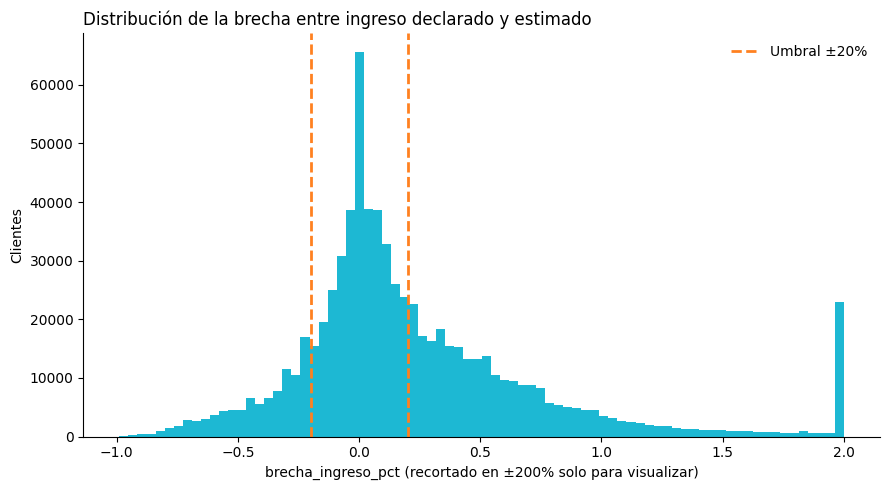

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(brecha_valida.clip(-2, 2), bins=80, color=PALETA["azul"])
ax.axvline(0.20, color=PALETA["naranja"], linestyle="--", linewidth=2, label="Umbral ±20%")
ax.axvline(-0.20, color=PALETA["naranja"], linestyle="--", linewidth=2)
ax.set_xlabel("brecha_ingreso_pct (recortado en ±200% solo para visualizar)")
ax.set_ylabel("Clientes")
ax.set_title("Distribución de la brecha entre ingreso declarado y estimado", fontsize=12, loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Esta gráfica compara el ingreso que los clientes declaran con el que se les estima, mostrando qué tan grande es la diferencia entre ambos valores. La mayoría de los clientes se concentra cerca del centro, es decir, con una brecha cercana a cero, lo que significa que para buena parte de la cartera el ingreso declarado y el estimado coinciden razonablemente bien. Las líneas naranjas marcan un margen de tolerancia del 20%, y se observa que una porción considerable de clientes queda fuera de ese rango, tanto por encima como por debajo, lo que indica que sus ingresos declarados se alejan de forma importante de lo esperado.

In [ ]:
condiciones = [
    resumen_estimador["tiene_estimador_ingreso"] == 0,
    resumen_estimador["brecha_ingreso_pct"] > 0.30,
    resumen_estimador["brecha_ingreso_pct"] < -0.30,
]
etiquetas = ["sin_dato", "subdeclara", "sobredeclara"]
resumen_estimador["perfil_ingreso"] = np.select(condiciones, etiquetas, default="consistente")

resumen_estimador["perfil_ingreso"].value_counts()

,count
perfil_ingreso,
consistente,440855
subdeclara,242266
sin_dato,114431
sobredeclara,62671


## Limpieza tabla invesbot.db

In [ ]:
df_invesbot

,fecha,numero_id,producto,saldo
0,2026-05-11,-4455498691690317961,INVESBOT,4.254059e+05
1,2025-11-25,7190472578366945756,INVESBOT,7.971988e+06
2,2025-06-24,-1237314025466821076,INVESBOT,1.730436e+05
3,2026-04-16,-375000770824817477,INVESBOT,2.743854e+07
4,2026-04-27,-2984135926251809763,INVESBOT,5.121209e+06
...,...,...,...,...
999995,2025-11-12,1588333962173777772,INVESBOT,1.265083e+08
999996,2026-03-31,5896145029139481778,INVESBOT,1.909002e+05
999997,2025-06-02,5630144609818050050,INVESBOT,1.921557e+07
999998,2025-09-02,8977050126033439627,INVESBOT,1.532147e+07


In [ ]:
df_invesbot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   fecha      1000000 non-null  object 
 1   numero_id  1000000 non-null  object 
 2   producto   1000000 non-null  object 
 3   saldo      1000000 non-null  float64
dtypes: float64(1), object(3)
memory usage: 30.5+ MB


In [ ]:
df_invesbot.isnull().sum()

,0
fecha,0
numero_id,0
producto,0
saldo,0


In [ ]:
df_invesbot.duplicated(subset=["fecha", "numero_id", "producto"]).sum()

np.int64(0)

In [ ]:
df_invesbot['producto'].value_counts()

,count
producto,
INVESBOT,1000000


In [ ]:
df_invesbot["fecha"] = pd.to_datetime(df_invesbot["fecha"])
df_invesbot["dia_mes"] = df_invesbot["fecha"].dt.day
df_invesbot["año_mes"] = df_invesbot["fecha"].dt.to_period("M")

In [ ]:
df_invesbot_mensual = (
    df_invesbot
    .sort_values("fecha")
    .groupby(["numero_id", "año_mes"], as_index=False)["saldo"]
    .last()
)

In [ ]:
resumen_invesbot = construir_resumen(df_invesbot_mensual, "saldo", "invesbot")

In [ ]:
resumen_invesbot

,numero_id,saldo_invesbot_mediana_historica,saldo_invesbot_min,saldo_invesbot_max,saldo_invesbot_ultimo,n_snapshots_invesbot,saldo_invesbot_rango_relativo,confianza_historia_invesbot
0,-1002497167780689628,2.954836e+06,215297.95,3437816.11,219224.09,13,1.090591,dato_robusto
1,-1005790337895894672,1.527753e+06,1000000.00,1960648.42,1960648.42,9,0.628798,dato_robusto
2,-1011019911553527198,1.002359e+05,99781.27,100690.43,100690.43,2,0.009070,dato_parcial
3,-1013877620442583184,9.931650e+04,99316.50,99316.50,99316.50,1,0.000000,dato_unico
4,-1014027667554002848,9.911720e+04,98629.41,99604.99,98629.41,2,0.009843,dato_parcial
...,...,...,...,...,...,...,...,...
5209,986764226228210032,3.456889e+07,32451137.83,36847613.20,36095103.00,13,0.127180,dato_robusto
5210,990598177592863004,1.250611e+05,49946.59,156472.93,154940.35,6,0.851794,dato_robusto
5211,99697724352913545,1.064397e+07,50209.73,40883089.04,40883089.04,6,3.836247,dato_robusto
5212,998125038507431790,3.469858e+07,7534523.19,45834764.49,19713781.75,13,1.103798,dato_robusto


## ABT (Analytical Base Table)

In [ ]:
abt = df_clientes.copy()

In [ ]:
# --- aho_cte (ahorro + corriente + sobregiro) ---
# Ensure 'numero_id' columns are of string type for consistent merging
abt["numero_id"] = abt["numero_id"].astype(str)
resumen_aho_cte["numero_id"] = resumen_aho_cte["numero_id"].astype(str)
abt = abt.merge(resumen_aho_cte, on="numero_id", how="left")

cols_aho_cte = [
    "saldo_ahorro_mediana_historica", "saldo_ahorro_min", "saldo_ahorro_max", "saldo_ahorro_ultimo", "n_snapshots_ahorro", "saldo_ahorro_rango_relativo",
    "saldo_corriente_mediana_historica", "saldo_corriente_min", "saldo_corriente_max", "saldo_corriente_ultimo", "n_snapshots_corriente", "saldo_corriente_rango_relativo",
]
for col in ["tiene_ahorro", "tiene_corriente", "tuvo_sobregiro", "tuvo_sobregiro_atipico"]:
    abt[col] = abt[col].fillna(0).astype(int)
abt[cols_aho_cte] = abt[cols_aho_cte].fillna(0)
for col in ["confianza_historia_ahorro", "confianza_historia_corriente"]:
    abt[col] = marcar_no_aplica(abt[col])

In [ ]:
# --- bolsillos (producto único: tiene_bolsillos se crea aquí) ---
abt = abt.merge(resumen_bolsillos, on="numero_id", how="left")
abt["tiene_bolsillos"] = abt["n_snapshots_bolsillos"].notna().astype(int)
cols_bolsillos = ["saldo_bolsillos_mediana_historica", "saldo_bolsillos_min", "saldo_bolsillos_max", "saldo_bolsillos_ultimo", "n_snapshots_bolsillos", "saldo_bolsillos_rango_relativo"]
abt[cols_bolsillos] = abt[cols_bolsillos].fillna(0)
abt["confianza_historia_bolsillos"] = marcar_no_aplica(abt["confianza_historia_bolsillos"])

In [ ]:
# --- fiducuenta (producto único) ---
abt = abt.merge(resumen_fiducuenta, on="numero_id", how="left")
abt["tiene_fiducuenta"] = abt["n_snapshots_fiducuenta"].notna().astype(int)
cols_fiducuenta = ["saldo_fiducuenta_mediana_historica", "saldo_fiducuenta_min", "saldo_fiducuenta_max", "saldo_fiducuenta_ultimo", "n_snapshots_fiducuenta", "saldo_fiducuenta_rango_relativo"]
abt[cols_fiducuenta] = abt[cols_fiducuenta].fillna(0)
abt["confianza_historia_fiducuenta"] = marcar_no_aplica(abt["confianza_historia_fiducuenta"])

In [ ]:
# --- inv_virtual_cdt (cdt + inversión virtual) ---
abt = abt.merge(resumen_inv_virtual_cdt, on="numero_id", how="left")
abt["tiene_cdt"] = abt["tiene_cdt"].fillna(0).astype(int)
abt["tiene_inv_virtual"] = abt["tiene_inv_virtual"].fillna(0).astype(int)
cols_inv_virtual_cdt = [
    "saldo_cdt_mediana_historica", "saldo_cdt_min", "saldo_cdt_max", "saldo_cdt_ultimo", "n_snapshots_cdt", "saldo_cdt_rango_relativo",
    "saldo_inversion_virtual_mediana_historica", "saldo_inversion_virtual_min", "saldo_inversion_virtual_max",
    "saldo_inversion_virtual_ultimo", "n_snapshots_inversion_virtual", "saldo_inversion_virtual_rango_relativo",
]
abt[cols_inv_virtual_cdt] = abt[cols_inv_virtual_cdt].fillna(0)
for col in ["confianza_historia_cdt", "confianza_historia_inversion_virtual"]:
    abt[col] = marcar_no_aplica(abt[col])

In [ ]:
# --- estimador_ing (ya viene a nivel del universo completo) ---
cols_estimador_nuevas = [c for c in resumen_estimador.columns if c not in ("numero_id", "ingresos_mensuales", "ingresos_mensuales_wz")]
abt = abt.merge(resumen_estimador[["numero_id"] + cols_estimador_nuevas], on="numero_id", how="left")

In [ ]:
# --- invesbot (producto único) ---
abt = abt.merge(resumen_invesbot, on="numero_id", how="left")
abt["tiene_invesbot"] = abt["n_snapshots_invesbot"].notna().astype(int)
cols_invesbot = ["saldo_invesbot_mediana_historica", "saldo_invesbot_min", "saldo_invesbot_max", "saldo_invesbot_ultimo", "n_snapshots_invesbot", "saldo_invesbot_rango_relativo"]
abt[cols_invesbot] = abt[cols_invesbot].fillna(0)
abt["confianza_historia_invesbot"] = marcar_no_aplica(abt["confianza_historia_invesbot"])

In [ ]:
abt.info()

In [ ]:
import sqlite3

conn = sqlite3.connect("/content/drive/MyDrive/data/abt_crean.db")
abt.to_sql("abt", conn, if_exists="replace", index=False, chunksize=50000)
conn.close()

In [ ]:
tablas = {
    # --- paneles mensuales ya limpios---
    "panel_aho_cte_mensual": df_aho_cte_mensual.assign(año_mes=lambda d: d["año_mes"].astype(str)),
    "panel_bolsillos_mensual": df_bolsillos_mensual.assign(año_mes=lambda d: d["año_mes"].astype(str)),
    "panel_fiducuenta_mensual": df_fiducuenta_mensual.assign(año_mes=lambda d: d["año_mes"].astype(str)),
    "panel_inv_virtual_cdt_mensual": df_inv_virtual_cdt_mensual.assign(año_mes=lambda d: d["año_mes"].astype(str)),
    "panel_invesbot_mensual": df_invesbot_mensual.assign(año_mes=lambda d: d["año_mes"].astype(str)),
}

for nombre, df in tablas.items():
    conn = sqlite3.connect(f"/content/drive/MyDrive/data/{nombre}.db")
    df.to_sql(nombre, conn, if_exists="replace", index=False, chunksize=50000)
    conn.close()
    print(f"{nombre}.db guardado -> {len(df):,} filas")


panel_aho_cte_mensual.db guardado -> 999,886 filas
panel_bolsillos_mensual.db guardado -> 997,547 filas
panel_fiducuenta_mensual.db guardado -> 999,806 filas
panel_inv_virtual_cdt_mensual.db guardado -> 785,369 filas
panel_invesbot_mensual.db guardado -> 42,979 filas


## Resumen y conclusiones de la capa bronze

Este notebook integra las siete fuentes (clientes, ahorro/corriente, bolsillos, fiducuenta, CDT/inversión virtual, estimador de ingresos, invesbot) en una única ABT de grano cliente — 860,223 filas, una por `numero_id`, verificada sin duplicación tras los cinco merges —, y deja aparte los paneles mensuales ya limpios para que el modelado de propensión y monto no tengan que reprocesar el dato crudo.

El hallazgo que más determina el resto del proyecto es la profundidad de historia: el panel es corto (~13 meses) y disperso — la mayoría de los clientes aparece muy pocas veces, ninguno con el historial mensual completo —, así que no hay con qué modelar una trayectoria real. Por eso la ABT se construye alrededor de estadísticos descriptivos por cliente (mediana, mínimo, máximo, estabilidad del saldo) en vez de tendencias, y cada uno de esos estadísticos viaja acompañado de su propio nivel de confianza (`confianza_historia`), para que quien los use después sepa qué tan sostenido está cada número. Ese mismo criterio reveló comportamientos distintos entre productos que justificaron tratamientos distintos: ahorro, corriente y bolsillos son volátiles por naturaleza (el cliente típico se mueve más del 100% de su saldo entre observaciones), fiducuenta es comparativamente estable (producto fiduciario, no transaccional), y solo CDT tiene panel suficientemente denso como para calcularle una tendencia real.

En el camino aparecieron varios problemas de calidad que sin corregir habrían llegado crudos a los modelos posteriores: outliers de varios billones de pesos en activos, pasivos, egresos y ambas colas de patrimonio (corregidos con el mismo criterio de winsorización dirigida, no un recorte parejo que hubiera aplastado variación legítima); una brecha entre ingreso declarado y estimado que es amplia y asimétrica para una porción grande y genuina de la base, no un artefacto de dato faltante; y un comportamiento de sobregiro tan raro (0.12% de la base) que solo tiene sentido leerlo junto con si el cliente siquiera tenía cuenta corriente para sobregirar.

La conclusión de fondo es que esta ABT prioriza trazabilidad sobre precisión aparente: ningún supuesto queda implícito, cada decisión de transformación está documentada en el punto donde se toma, y las banderas de confianza permiten que los modelos de adopción y monto potencial hereden honestamente las limitaciones reales del dato, en vez de una base que aparente más certeza de la que los datos sostienen.